# Multiple Game Analysis

## Loading all the libraries

In [36]:
import matplotlib.pyplot as plt
import numpy as np
from adjustText import *
import pandas as pd
from plotnine import *
import scipy.stats as st
from scipy.interpolate import interp1d

from matplotlib.ticker import MaxNLocator
%matplotlib inline

# Game Set for Analysis

Each game to evaluate should be on a different line in "games".

In [102]:
fileprefix = "../CardStock/output/TraditionalTestbedNov17/"
games = [
    {"game":"Agram","name":"Agram", "player":3},
    {"game":"Blackjack","name":"Blackjack", "player":1},
    {"game":"CrazyEights","name":"Crazy Eights", "player":3},
    {"game":"Cribbage","name":"Cribbage", "player":2},
    {"game":"Cuckoo","name":"Cuckoo", "player":6},
    {"game":"Euchre","name":"Euchre", "player":4},
    {"game":"GoFish","name":"Go Fish", "player":4},
    {"game":"GolfSix","name":"Golf-6", "player":4},
    {"game":"GOPS","name":"Goofspiel", "player":2},
    {"game":"Hearts","name":"Hearts", "player": 4},
    {"game":"Klaverjassen","name":"Klaverjassen", "player":4},
    {"game":"LeducPoker","name":"Leudec Hold'em", "player":2},
    {"game":"Pitch","name":"Pitch", "player":4},
    {"game":"President","name":"President", "player":5},
    {"game":"Rummy","name":"Rummy", "player":2},
    {"game":"Schwimmen","name":"Schwimmen", "player":5},
    {"game":"Scopa","name":"Scopa", "player":2},
    {"game":"Skittgube","name":"Skittgube", "player":3},
    {"game":"Sueca","name":"Sueca", "player":4},
    {"game":"Whist","name":"Whist", "player":4},    
]
gameframe = pd.DataFrame.from_dict(games)
gameframe["fileprefix"] = fileprefix
gameframe

,game,name,player,fileprefix
0,Agram,Agram,3,../CardStock/output/TraditionalTestbedNov17/
1,Blackjack,Blackjack,1,../CardStock/output/TraditionalTestbedNov17/
2,CrazyEights,Crazy Eights,3,../CardStock/output/TraditionalTestbedNov17/
3,Cribbage,Cribbage,2,../CardStock/output/TraditionalTestbedNov17/
4,Cuckoo,Cuckoo,6,../CardStock/output/TraditionalTestbedNov17/
5,Euchre,Euchre,4,../CardStock/output/TraditionalTestbedNov17/
6,GoFish,Go Fish,4,../CardStock/output/TraditionalTestbedNov17/
7,GolfSix,Golf-6,4,../CardStock/output/TraditionalTestbedNov17/
8,GOPS,Goofspiel,2,../CardStock/output/TraditionalTestbedNov17/
9,Hearts,Hearts,4,../CardStock/output/TraditionalTestbedNov17/


In [101]:
fileprefix = "../CardStock/output/"
games = [

    {"game":"ShastaSam","name":"Shasta Sam", "player":2},
    {"game":"CaliforniaJack","name":"California Jack", "player":2},
    {"game":"Caterpillar","name":"Caterpillar", "player":2},
    {"game":"Coloretto","name":"Coloretto", "player":4},
    {"game":"Comet","name":"Comet", "player":2},
#    {"game":"Coup","name":"Coup", "player":4},
    {"game":"Escoba","name":"Escoba", "player":2},
    {"game":"LostCities","name":"Lost Cities", "player":2},
    {"game":"LAMA","name":"LAMA", "player":4},
    {"game":"NoThanks","name":"No Thanks", "player":4},
    {"game":"PageOne","name":"Page One", "player":3},
    {"game":"Knaves","name":"Knaves", "player":3},
    {"game":"NinetyEight","name":"Ninety Eight", "player":4},
    {"game":"SaneEights","name":"Sane Eights", "player":4},
    {"game":"SheepsheadPicker","name":"Sheepshead", "player":5},
    {"game":"Simon'sCat","name":"Simon's Cat", "player":4},
    {"game":"SpiteMalice","name":"Spite and Malice", "player":2},
    {"game":"TurnTheTide","name":"Turn The Tide", "player":3},
    {"game":"BottleImp","name":"The Bottle Imp", "player":3},
    {"game":"Pairs","name":"Pairs", "player":3},
    {"game":"PairsPort","name":"Pairs Port", "player":4},
    {"game":"Clocktowers","name":"Clocktowers", "player":2},
    {"game":"Briscola","name":"Briscola", "player":2},
    {"game":"Trifle","name":"Trifle", "player":2},
    {"game":"SixNimmt","name":"6 Nimmt", "player":5},
    {"game":"FoxInTheForest","name":"The Fox in the Forest", "player":2},
    {"game":"GermanWhist","name":"German Whist", "player":2},
    {"game":"Slobberhannes","name":"Slobberhannes", "player":4},
    {"game":"Polignac","name":"Polignac", "player":4},
    {"game":"StealingBundles","name":"Stealing Bundles", "player":2},
    {"game":"DuckSoup","name":"Duck Soup", "player":2},
    {"game":"Pico","name":"Pico", "player":2},
    {"game":"PicoTwo","name":"Pico 2", "player":2},
#    {"game":"Trio","name":"Trio", "player":4},
    {"game":"Diamant","name":"Diamant", "player":8},
    {"game":"LoveLetter","name":"Love Letter", "player":4},
    {"game":"Poison","name":"Poison", "player":5},
#    {"game":"Escalation","name":"Escalation!", "player":4},
#    {"game":"GoldRush","name":"Gold Rush!", "player":3},
    {"game":"AbandonAllArtichokes","name":"Abandon All Artichokes", "player":2},
    {"game":"Nanuk","name":"Nanuk", "player":6},
    {"game":"SushiGo","name":"Sushi Go!", "player":4},

]
gameframe = pd.DataFrame.from_dict(games)
gameframe["fileprefix"] = fileprefix
#gameframe = pd.concat([gameframe, gameframe2])
gameframe

,game,name,player,fileprefix
0,ShastaSam,Shasta Sam,2,../CardStock/output/
1,CaliforniaJack,California Jack,2,../CardStock/output/
2,Caterpillar,Caterpillar,2,../CardStock/output/
3,Coloretto,Coloretto,4,../CardStock/output/
4,Comet,Comet,2,../CardStock/output/
5,Escoba,Escoba,2,../CardStock/output/
6,LostCities,Lost Cities,2,../CardStock/output/
7,LAMA,LAMA,4,../CardStock/output/
8,NoThanks,No Thanks,4,../CardStock/output/
9,PageOne,Page One,3,../CardStock/output/


# Branching Factor

This first gather data into a dataframe, which will enable us to draw graphs to show how the branching factor of the game changes over time.

This data is from games with all **random** players.

In [38]:
first = True
for index, row in gameframe.iterrows():
    gf = pd.read_csv(row["fileprefix"] + row["game"] + "/" + str(row["player"]) + "/" + "R" * row["player"] + "/choice.csv")
    print(row["game"])
    gf["game"] = row["game"]
    if first:
        choiceframe = gf
        first = False
    else:
        choiceframe = pd.concat([choiceframe, gf])
    gf = pd.read_csv(row["fileprefix"] + row["game"] + "/" + str(row["player"]) + "/" + "P" + "R" * (row["player"] - 1) + "/choice.csv")
    gf["game"] = row["game"]
    choiceframe = pd.concat([choiceframe, gf])

Agram
Blackjack
CrazyEights
Cribbage
Cuckoo
Euchre
GoFish
GolfSix
GOPS
Hearts
Klaverjassen
LeducPoker
Pitch
President
Rummy
Schwimmen
Scopa
Skittgube
Sueca
Whist


In [39]:
choiceframe

,game,numPlayers,ai,run,move,player,choices,choice,time
0,Agram,3,RRR,1,1,1,6,4,0
1,Agram,3,RRR,1,2,2,6,4,0
2,Agram,3,RRR,1,3,3,3,3,0
3,Agram,3,RRR,1,4,1,5,3,0
4,Agram,3,RRR,1,5,2,1,1,0
...,...,...,...,...,...,...,...,...,...
5195,Whist,4,PRRR,100,48,3,2,2,0
5196,Whist,4,PRRR,100,49,4,1,1,0
5197,Whist,4,PRRR,100,50,1,1,1,1
5198,Whist,4,PRRR,100,51,2,1,1,0


## Convergence

The **Convergence** is a summary, the average slope of all the runs for a game, squished into a number between 0 and 1. 0.5 means a flat horizontal line, 0 is straight up, and 1 is straight down.

In [40]:
cseq = []
cf = choiceframe[choiceframe["ai"].str.startswith("R")]
for index, row in gameframe.iterrows():
    print(row["game"])
    cf2 = cf[(cf["game"]==row["game"])]
    convergence = 0
    count = 0
    for i in range(100):
        tempf = cf2[(cf2["run"]==i)]
        if len(tempf) > 1:
            slope, intercept, r_value, p_value, std_error = st.linregress(tempf["move"], tempf["choices"])
            convergence += (1 - (slope / 2 + 0.5))
            count += 1
    cseq.append(convergence / count)

Agram
Blackjack
CrazyEights
Cribbage
Cuckoo
Euchre
GoFish
GolfSix
GOPS
Hearts
Klaverjassen
LeducPoker
Pitch
President
Rummy
Schwimmen
Scopa
Skittgube
Sueca
Whist


In [41]:
gameframe["convergence"] = cseq
gameframe

,game,name,player,fileprefix,convergence
0,Agram,Agram,3,../CardStock/output/TraditionalTestbedNov4/,0.593593
1,Blackjack,Blackjack,1,../CardStock/output/TraditionalTestbedNov4/,1.123593
2,CrazyEights,Crazy Eights,3,../CardStock/output/TraditionalTestbedNov4/,0.523546
3,Cribbage,Cribbage,2,../CardStock/output/TraditionalTestbedNov4/,0.553883
4,Cuckoo,Cuckoo,6,../CardStock/output/TraditionalTestbedNov4/,0.503175
5,Euchre,Euchre,4,../CardStock/output/TraditionalTestbedNov4/,0.537285
6,GoFish,Go Fish,4,../CardStock/output/TraditionalTestbedNov4/,0.501628
7,GolfSix,Golf-6,4,../CardStock/output/TraditionalTestbedNov4/,0.505831
8,GOPS,Goofspiel,2,../CardStock/output/TraditionalTestbedNov4/,0.748889
9,Hearts,Hearts,4,../CardStock/output/TraditionalTestbedNov4/,0.538321


## Plotting all games

This plot shows the branching factors over all of the games in the testbed for random players.

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6 x 6 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: ChoicesRandom.png


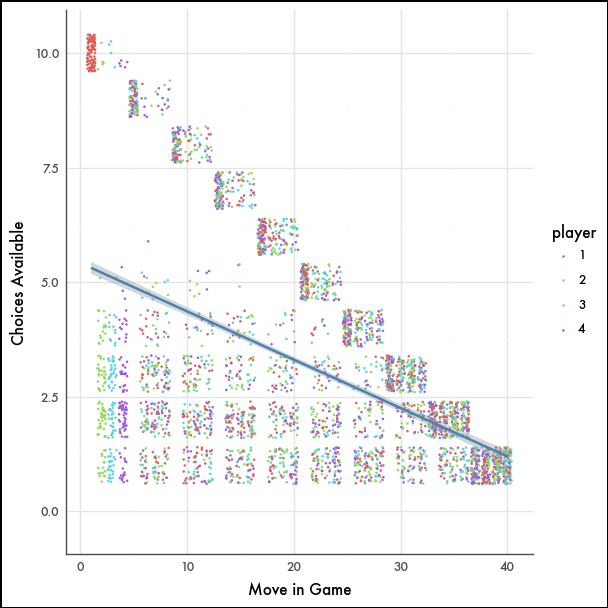

In [42]:
game = "Sueca"
choiceframe["player"] = choiceframe["player"].astype(str)
cplot = (ggplot(choiceframe[(choiceframe["ai"].str.startswith("R")) & (choiceframe["game"] == game)], aes("move", "choices", color="player"))
 + geom_jitter(size=0.05, alpha=0.9)
 + geom_smooth(method="lm", color="steelblue")
 + aes(ymin=0)
 + theme_minimal(base_family="Futura", base_size=11) 
 + theme(figure_size=(6, 6))
 + theme(
        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        panel_spacing=0.03,
    )
 + labs(x='Move in Game', y='Choices Available')
)
cplot.save("ChoicesRandom.png")
cplot.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 10 x 8 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: ChoicesRandom.png


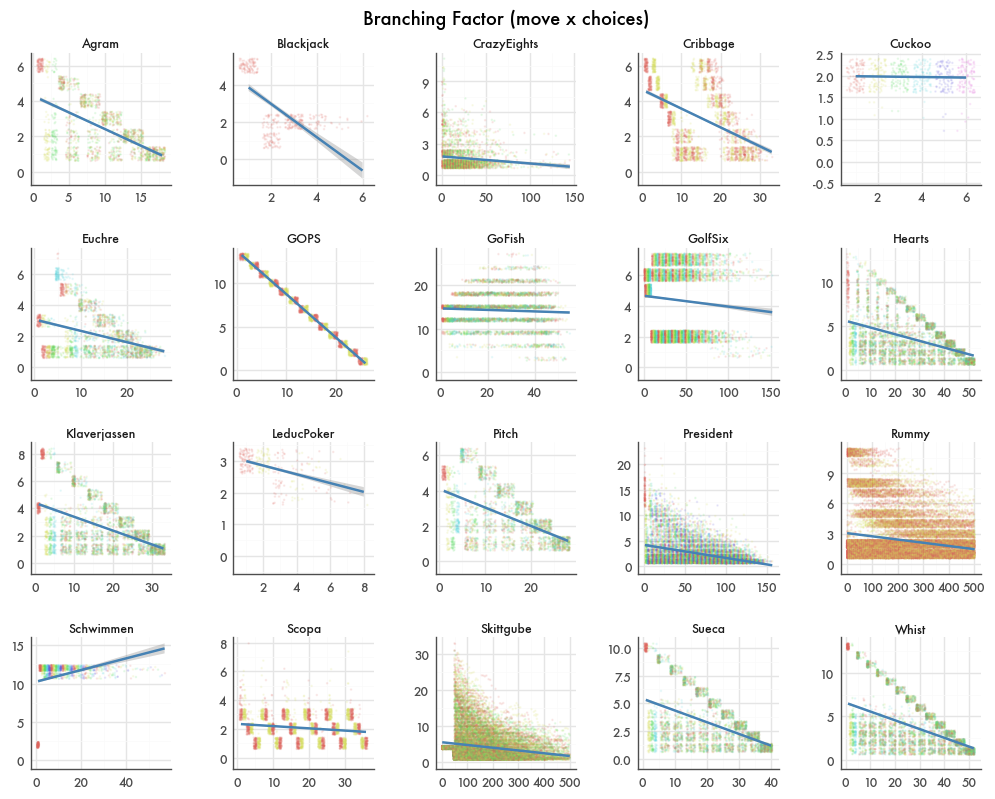

In [43]:
choiceframe["player"] = choiceframe["player"].astype(str)
cplot = (ggplot(choiceframe[choiceframe["ai"].str.startswith("R")], aes("move", "choices", color="player"))
 + geom_jitter(size=0.05, alpha=0.1)
 + geom_smooth(method="lm", color="steelblue")
 + facet_wrap("game", scales = "free", ncol = 5)
 + aes(ymin=0)
 + theme_minimal(base_family="Futura", base_size=11) 
 + theme(legend_position='none', figure_size=(10, 8))
 + theme(
#        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        axis_title=element_blank(),
        panel_spacing=0.03,
     
    )
 + labs(x='Move', y='Branching Factor', title="Branching Factor (move x choices)")
)
cplot.save("ChoicesRandom.png")
cplot.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 10 x 8 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: ChoicesRandom.png


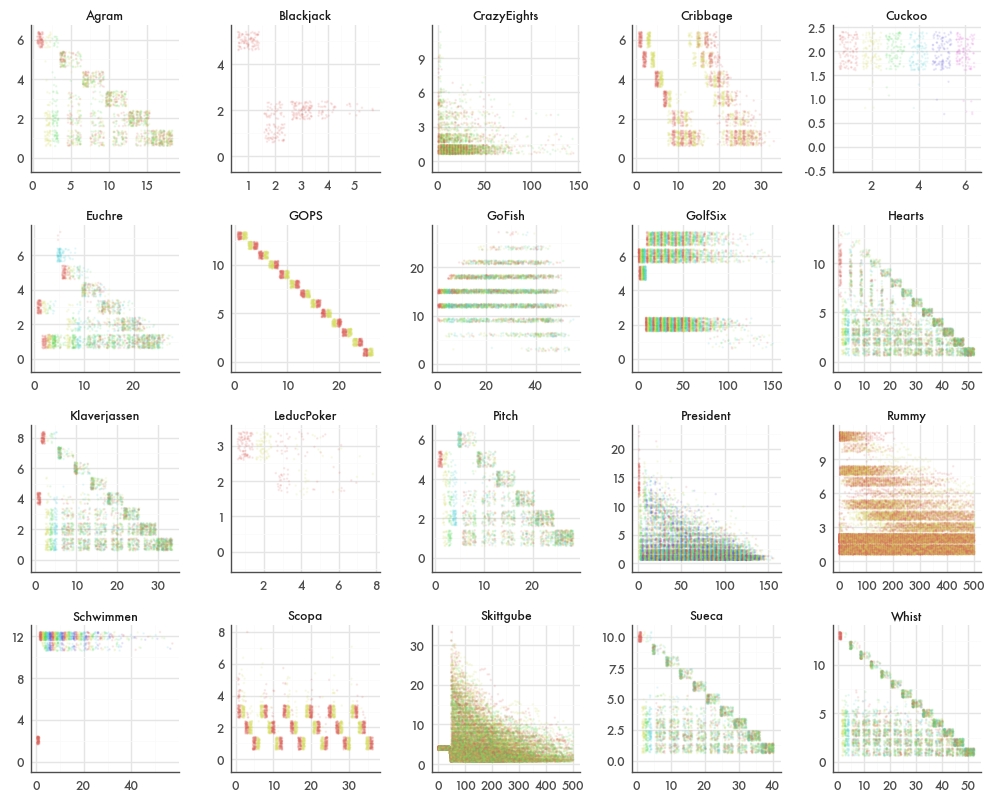

In [44]:
choiceframe["player"] = choiceframe["player"].astype(str)
cplot = (ggplot(choiceframe[choiceframe["ai"].str.startswith("R")], aes("move", "choices", color="player"))
 + geom_jitter(size=0.05, alpha=0.1)
 + facet_wrap("game", scales = "free", ncol = 5)
 + aes(ymin=0)
 + theme_minimal(base_family="Futura", base_size=11) 
 + theme(legend_position='none', figure_size=(10, 8))
 + theme(
#        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        axis_title=element_blank(),
        panel_spacing=0.02,
     
    )
)
cplot.save("ChoicesRandom.png")
cplot.show()

This plot is the branching factor for the PIPMC players

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 14 x 14 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: ChoicesPIPMC.png


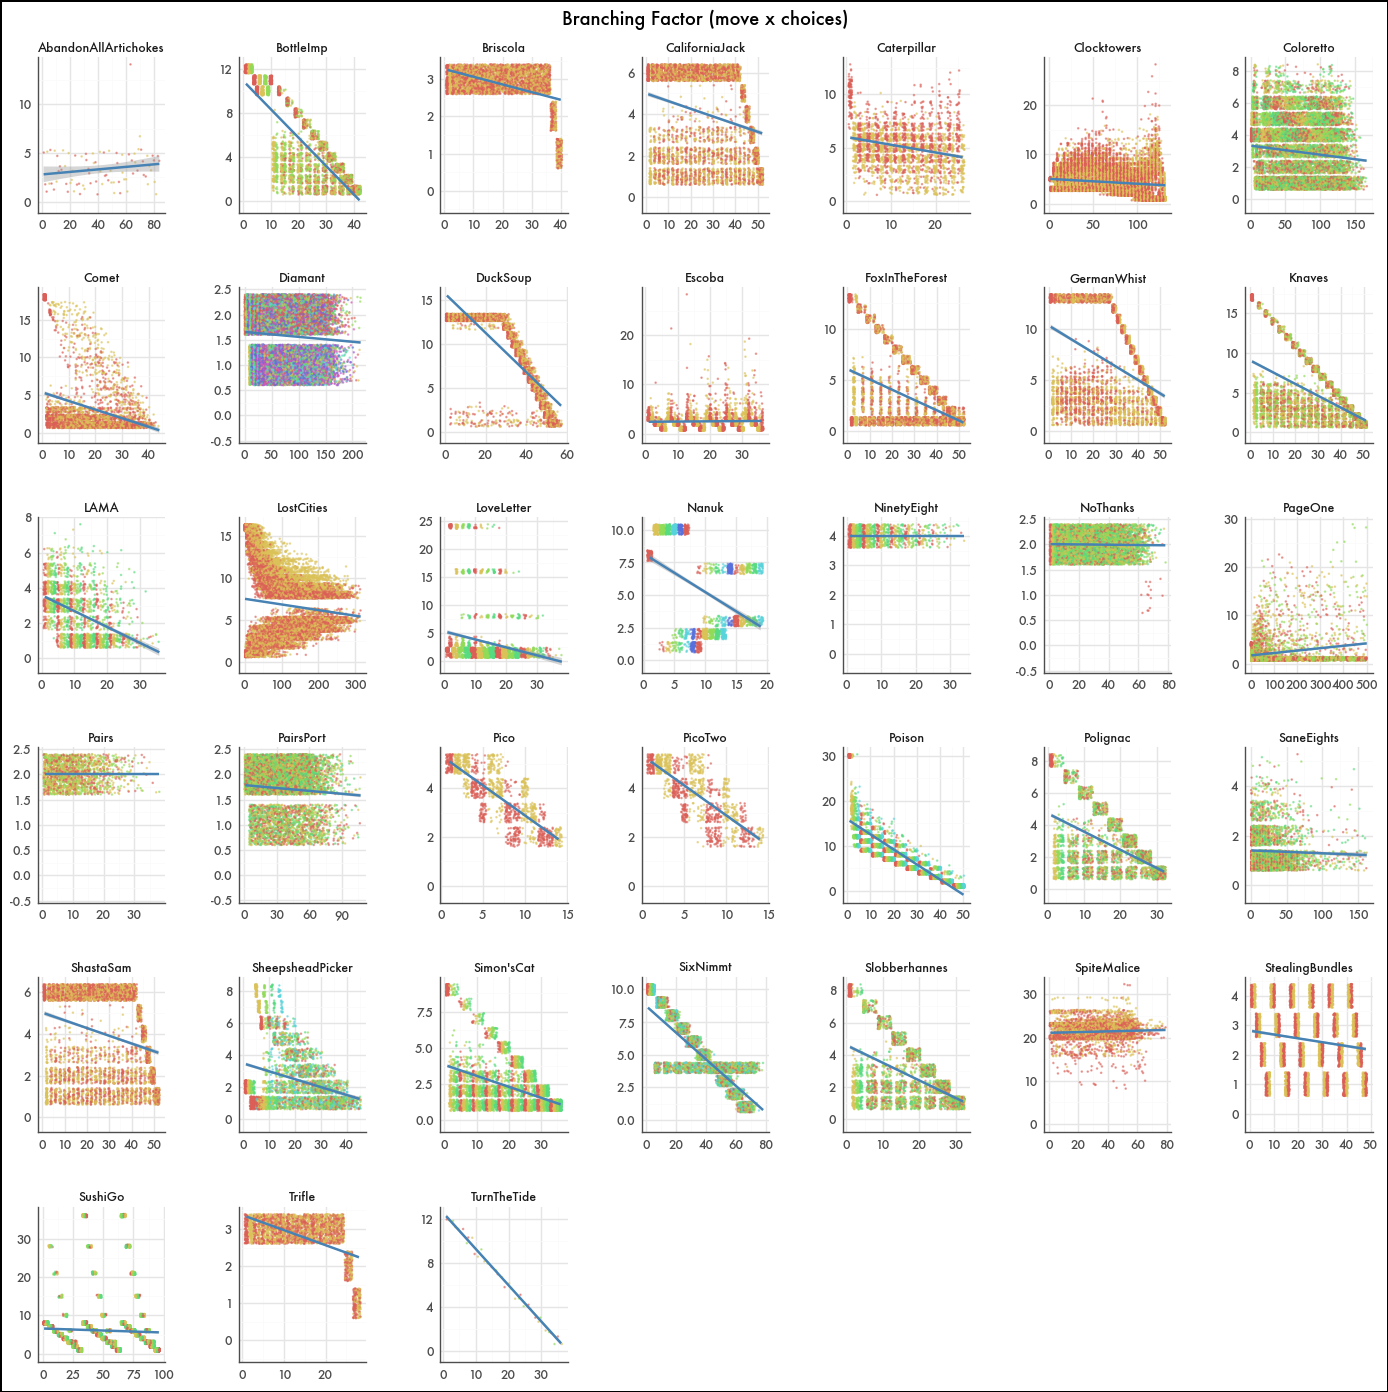

In [46]:
choiceframe["player"] = choiceframe["player"].astype(str)
cplot = (ggplot(choiceframe[choiceframe["ai"].str.startswith("P")], aes("move", "choices", color="player"))
 + geom_jitter(size=0.05, alpha=0.5)
 + geom_smooth(method="lm", color="steelblue")
 + facet_wrap("game", scales = "free", ncol = 7)
 + aes(ymin=0)
 + theme_minimal(base_family="Futura", base_size=11) 
 + theme(legend_position='none', figure_size=(14, 14))
 + theme(
        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        axis_title=element_blank(),
        panel_spacing=0.03,
    )
 + labs(x='Move', y='Branching Factor', title="Branching Factor (move x choices)")
)
cplot.save("ChoicesPIPMC.png")
cplot.show()

And one plot that shows them all.

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 10 x 20 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Choices.png


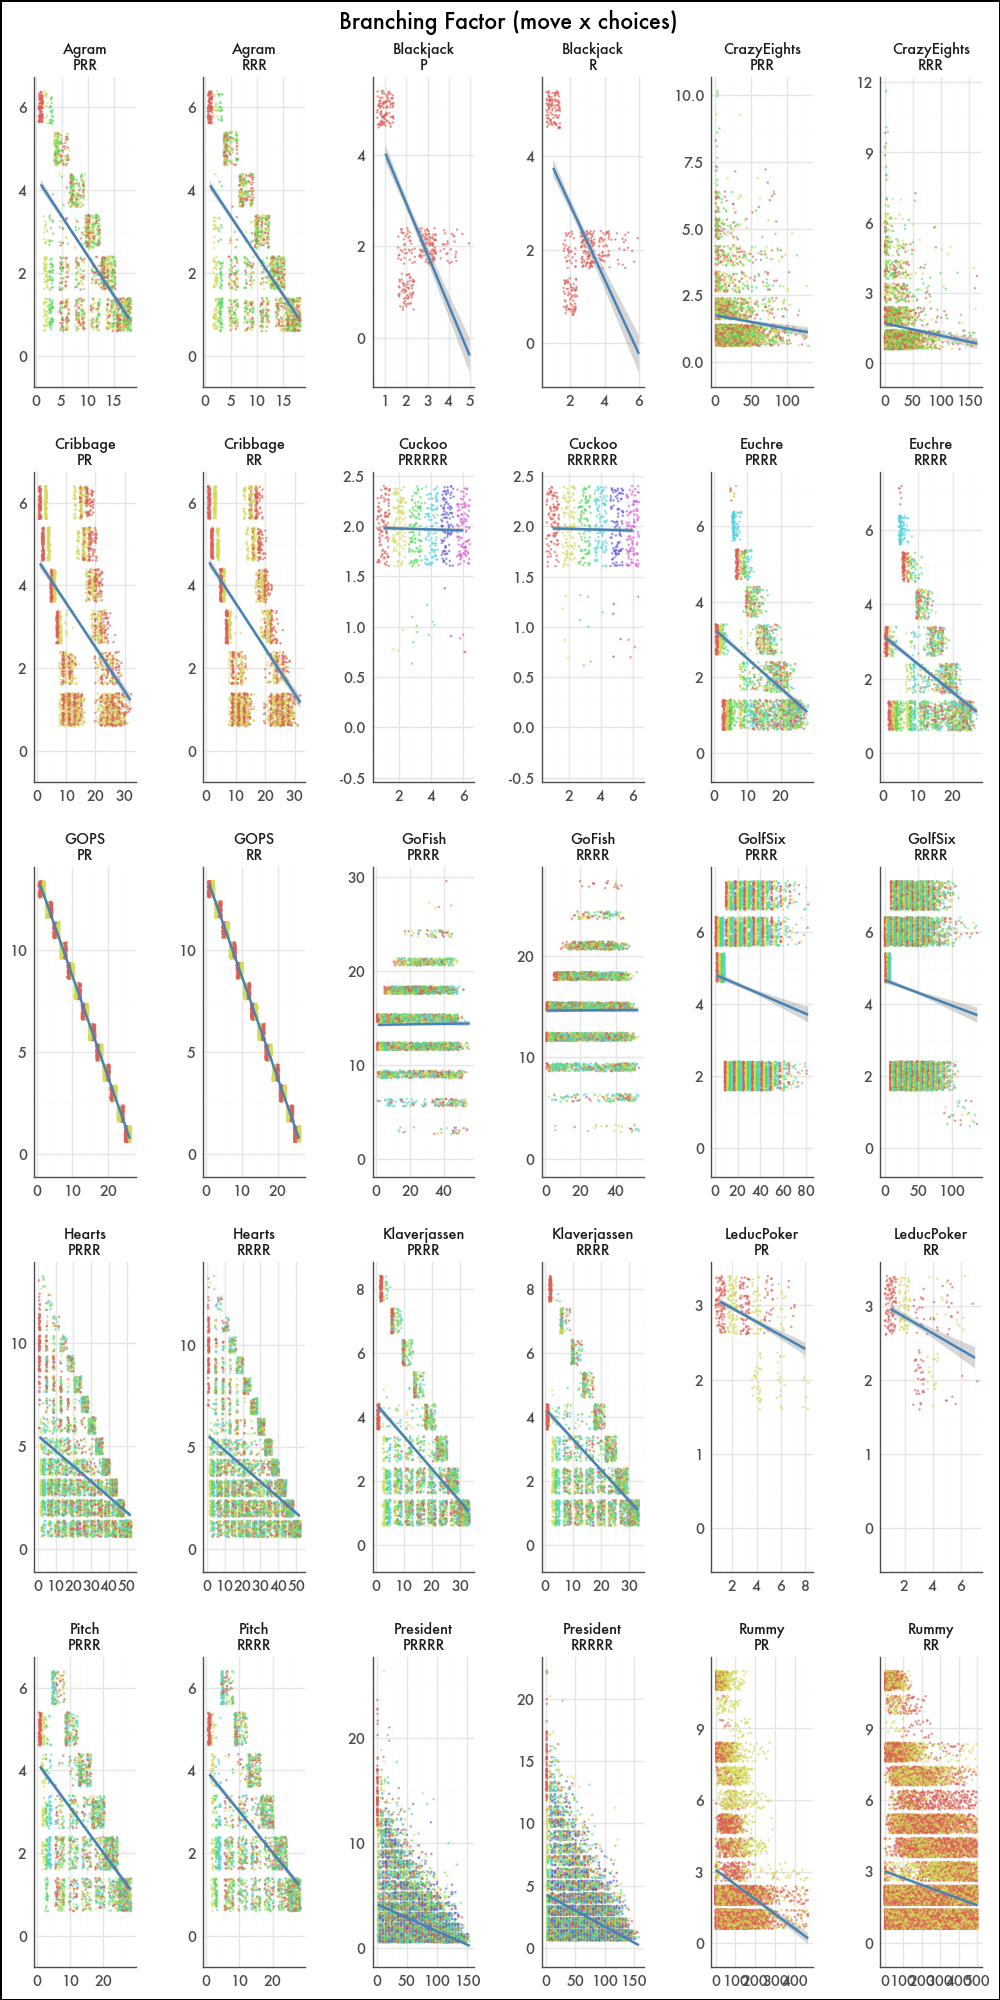

In [10]:
choiceframe["player"] = choiceframe["player"].astype(str)
cplot = (ggplot(choiceframe, aes("move", "choices", color="player"))
 + geom_jitter(size=0.05, alpha=0.5)
 + geom_smooth(method="lm", color="steelblue")
 + facet_wrap(["game", "ai"], scales = "free", ncol = 6)
 + aes(ymin=0)
 + theme_minimal(base_family="Futura", base_size=13) 
 + theme(legend_position='none', figure_size=(10, 20))
 + theme(
        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        axis_title=element_blank(),
        panel_spacing=0.03,
    )
 + labs(x='Move', y='Branching Factor', title="Branching Factor (move x choices)")
)
cplot.save("Choices.png")
cplot.show()

# Game Length

We can calculate the average game length, by finding the max value for the move column on each run, then averaging

In [45]:
choiceframe[['game', 'run', 'move']][choiceframe["ai"].str.startswith("R")].groupby(['game', 'run'], as_index=False)['move'].max().groupby(['game'], as_index=False).mean()

,game,run,move
0,Agram,50.5,18.00
1,Blackjack,50.5,3.44
2,CrazyEights,50.5,34.70
3,Cribbage,50.5,27.79
4,Cuckoo,50.5,6.00
5,Euchre,50.5,24.66
6,GOPS,50.5,26.00
7,GoFish,50.5,46.91
8,GolfSix,50.5,67.26
9,Hearts,50.5,52.00


In [49]:
lengthframe = choiceframe[['game', 'run', 'move']][choiceframe["ai"].str.startswith("R")].groupby(['game', 'run'], as_index=False)['move'].max()
lengthframe

,game,run,move
0,Agram,1,18
1,Agram,2,18
2,Agram,3,18
3,Agram,4,18
4,Agram,5,18
...,...,...,...
1995,Whist,96,52
1996,Whist,97,52
1997,Whist,98,52
1998,Whist,99,52


/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 10 x 5 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Length.png


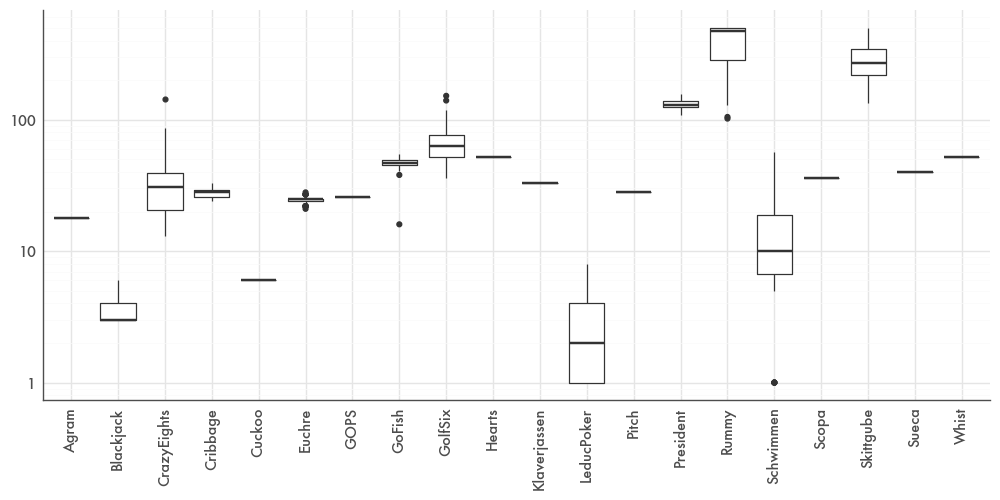

In [55]:
lplot = (ggplot(lengthframe, aes("game", "move"))
 + geom_boxplot()
 + theme_minimal(base_family="Futura", base_size=13) 
 + theme(legend_position='none', figure_size=(10, 5))
 + theme(
        axis_text_x=element_text(rotation=90),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        axis_title=element_blank(),
        panel_spacing=0.03,
    )
 + scale_y_log10()         
)
lplot.save("Length.png")
lplot.show()

In [48]:
lengthf = choiceframe[['game', 'run', 'move']][choiceframe["ai"].str.startswith("R")].groupby(['game', 'run'], as_index=False)['move'].max().groupby(['game'], as_index=False).mean()[['game', 'move']]
gameframe = gameframe.merge(lengthf, on='game', how='left')

In [49]:
gameframe

,game,name,player,fileprefix,convergence,move
0,ShastaSam,Shasta Sam,2,../CardStock/output/,0.518177,52.00
1,CaliforniaJack,California Jack,2,../CardStock/output/,0.518890,52.00
2,Caterpillar,Caterpillar,2,../CardStock/output/,0.570266,24.51
3,Coloretto,Coloretto,4,../CardStock/output/,0.501806,132.90
4,Comet,Comet,2,../CardStock/output/,0.563324,38.68
5,Escoba,Escoba,2,../CardStock/output/,0.501216,36.00
6,LostCities,Lost Cities,2,../CardStock/output/,0.503004,279.60
7,LAMA,LAMA,4,../CardStock/output/,0.571281,19.14
8,NoThanks,No Thanks,4,../CardStock/output/,0.500000,47.87
9,PageOne,Page One,3,../CardStock/output/,0.516064,53.00


# Results

For random games, we want to look at the distribution of win/loss percentages across the players.

In [103]:
first = True
for index, row in gameframe.iterrows():
    print(row["game"])
    gf = pd.read_csv(row["fileprefix"] + row["game"] + "/" + str(row["player"]) + "/" + "R" * row["player"] + "/results.csv")
    if row["game"] == "Schwimmen":
        gf["score"] = gf["score"] / 2.0
    gf["game"] = row["game"]
    gf["ai"] = "Random"
    if first:
        resultsframe = gf
        first = False
    else:
        resultsframe = pd.concat([resultsframe, gf])
    gf = pd.read_csv(row["fileprefix"] + row["game"] + "/" + str(row["player"]) + "/" + "P" + "R" * (row["player"] - 1) + "/results.csv")
    if row["game"] == "Schwimmen":
        gf["score"] = gf["score"] / 2.0
    gf["game"] = row["game"]
    gf["ai"] = "PIMC"
    resultsframe = pd.concat([resultsframe, gf])

resultsframe["player"] = resultsframe["player"].astype(str)
resultsframe["rank"] = resultsframe["rank"].astype(str)
resultsframe

Agram
Blackjack
CrazyEights
Cribbage
Cuckoo
Euchre
GoFish
GolfSix
GOPS
Hearts
Klaverjassen
LeducPoker
Pitch
President
Rummy
Schwimmen
Scopa
Skittgube
Sueca
Whist


,game,numPlayers,ai,run,player,score,rank,time
0,Agram,3,Random,1,1,0.0,2,23.0565
1,Agram,3,Random,1,2,0.0,2,23.0565
2,Agram,3,Random,1,3,1.0,1,23.0565
3,Agram,3,Random,2,1,1.0,1,2.4661
4,Agram,3,Random,2,2,0.0,2,2.4661
...,...,...,...,...,...,...,...,...
395,Whist,4,PIMC,99,4,0.0,3,32332.7254
396,Whist,4,PIMC,100,1,0.0,3,35547.7700
397,Whist,4,PIMC,100,2,4.0,1,35547.7700
398,Whist,4,PIMC,100,3,0.0,3,35547.7700


# Timing

In [104]:
pgames = resultsframe[['game', 'run', 'ai', 'time']]
what = pgames.groupby(['game', 'run', 'ai'], as_index=False)['time'].max()
timef = what.groupby(['game', 'ai'], as_index=False).median()[['game', 'time', 'ai']]
timef

,game,time,ai
0,Agram,2289.20000,PIMC
1,Agram,2.32685,Random
2,Blackjack,375.41810,PIMC
3,Blackjack,0.35535,Random
4,CrazyEights,11271.62795,PIMC
5,CrazyEights,2.77695,Random
6,Cribbage,18612.66495,PIMC
7,Cribbage,1.94955,Random
8,Cuckoo,171.45130,PIMC
9,Cuckoo,0.29165,Random


/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 8 x 5 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Time.png


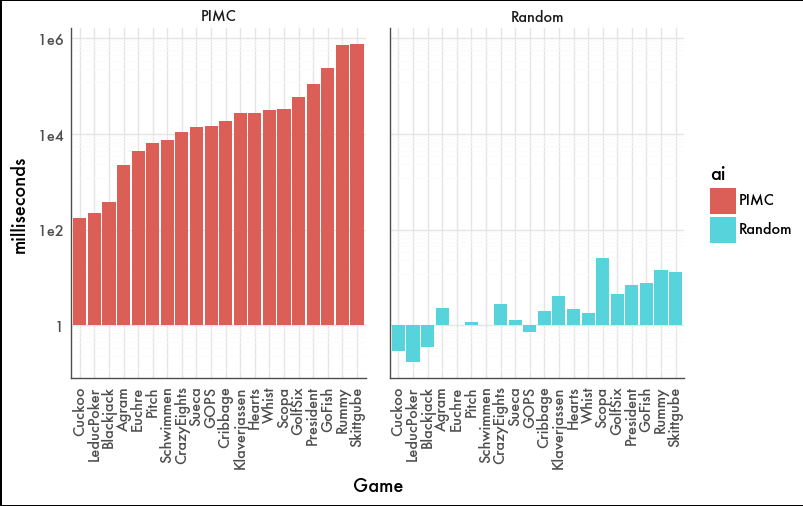

In [105]:
rplot = (ggplot(timef, aes("reorder(game, time)", "time", fill="ai"))
 + geom_bar(position="dodge", stat="identity")
 + facet_wrap(["ai"])
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(figure_size=(8, 5))
 + theme(
        axis_text_x=element_text(rotation=90),
        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        panel_spacing=0.03,
    )
 + labs(x='Game', y='milliseconds')
 + scale_y_log10()
)
rplot.save("Time.png")
rplot.show()

In [106]:
rf2 = resultsframe.groupby(['game', 'player', 'rank', 'ai'], as_index=False).count()
rf3 = rf2[(rf2["player"]=="1") & (rf2["rank"] == "1")][["game", "ai", "run"]]
rf3["run"] = rf3["run"] / 100
rf4 = rf3.pivot(index='game', columns='ai')
rf4 = rf4["run"].reset_index()
rf4.columns.name=None
rf5 = rf4.merge(gameframe, on='game', how='left')
rf5

,game,PIMC,Random,name,player,fileprefix
0,Agram,0.54,0.34,Agram,3,../CardStock/output/TraditionalTestbedNov17/
1,Blackjack,1.00,1.00,Blackjack,1,../CardStock/output/TraditionalTestbedNov17/
2,CrazyEights,0.48,0.38,Crazy Eights,3,../CardStock/output/TraditionalTestbedNov17/
3,Cribbage,0.86,0.57,Cribbage,2,../CardStock/output/TraditionalTestbedNov17/
4,Cuckoo,0.95,0.77,Cuckoo,6,../CardStock/output/TraditionalTestbedNov17/
5,Euchre,0.61,0.32,Euchre,4,../CardStock/output/TraditionalTestbedNov17/
6,GOPS,0.90,0.53,Goofspiel,2,../CardStock/output/TraditionalTestbedNov17/
7,GoFish,0.41,0.33,Go Fish,4,../CardStock/output/TraditionalTestbedNov17/
8,GolfSix,0.92,0.25,Golf-6,4,../CardStock/output/TraditionalTestbedNov17/
9,Hearts,0.73,0.34,Hearts,4,../CardStock/output/TraditionalTestbedNov17/


In [107]:
def fairness(wp, np):
    if np == 1:
        return 1
    if wp < 1 / np:
        return wp * np
    else:
        return (np - np * wp) / (np - 1)
rf5["fairness"] = rf5.apply(lambda x: fairness(x.Random, x.player), axis=1)
def order(aiwp, np):
    if np == 1:
        return 1
    ewp = 1 / np
    return (aiwp - ewp) / (1 - ewp)
rf5["order"] = rf5.apply(lambda x: order(x.PIMC, x.player), axis=1)
rf5["gain"] = rf5.apply(lambda x: x.PIMC - x.Random, axis=1)
rf5

,game,PIMC,Random,name,player,fileprefix,fairness,order,gain
0,Agram,0.54,0.34,Agram,3,../CardStock/output/TraditionalTestbedNov17/,0.990000,0.310000,0.20
1,Blackjack,1.00,1.00,Blackjack,1,../CardStock/output/TraditionalTestbedNov17/,1.000000,1.000000,0.00
2,CrazyEights,0.48,0.38,Crazy Eights,3,../CardStock/output/TraditionalTestbedNov17/,0.930000,0.220000,0.10
3,Cribbage,0.86,0.57,Cribbage,2,../CardStock/output/TraditionalTestbedNov17/,0.860000,0.720000,0.29
4,Cuckoo,0.95,0.77,Cuckoo,6,../CardStock/output/TraditionalTestbedNov17/,0.276000,0.940000,0.18
5,Euchre,0.61,0.32,Euchre,4,../CardStock/output/TraditionalTestbedNov17/,0.906667,0.480000,0.29
6,GOPS,0.90,0.53,Goofspiel,2,../CardStock/output/TraditionalTestbedNov17/,0.940000,0.800000,0.37
7,GoFish,0.41,0.33,Go Fish,4,../CardStock/output/TraditionalTestbedNov17/,0.893333,0.213333,0.08
8,GolfSix,0.92,0.25,Golf-6,4,../CardStock/output/TraditionalTestbedNov17/,1.000000,0.893333,0.67
9,Hearts,0.73,0.34,Hearts,4,../CardStock/output/TraditionalTestbedNov17/,0.880000,0.640000,0.39


In [108]:
gameframe = gameframe.merge(rf5[["game", "fairness", "order", "gain", "PIMC"]], on="game", how="left")

In [109]:
gameframe

,game,name,player,fileprefix,fairness,order,gain,PIMC
0,Agram,Agram,3,../CardStock/output/TraditionalTestbedNov17/,0.990000,0.310000,0.20,0.54
1,Blackjack,Blackjack,1,../CardStock/output/TraditionalTestbedNov17/,1.000000,1.000000,0.00,1.00
2,CrazyEights,Crazy Eights,3,../CardStock/output/TraditionalTestbedNov17/,0.930000,0.220000,0.10,0.48
3,Cribbage,Cribbage,2,../CardStock/output/TraditionalTestbedNov17/,0.860000,0.720000,0.29,0.86
4,Cuckoo,Cuckoo,6,../CardStock/output/TraditionalTestbedNov17/,0.276000,0.940000,0.18,0.95
5,Euchre,Euchre,4,../CardStock/output/TraditionalTestbedNov17/,0.906667,0.480000,0.29,0.61
6,GoFish,Go Fish,4,../CardStock/output/TraditionalTestbedNov17/,0.893333,0.213333,0.08,0.41
7,GolfSix,Golf-6,4,../CardStock/output/TraditionalTestbedNov17/,1.000000,0.893333,0.67,0.92
8,GOPS,Goofspiel,2,../CardStock/output/TraditionalTestbedNov17/,0.940000,0.800000,0.37,0.90
9,Hearts,Hearts,4,../CardStock/output/TraditionalTestbedNov17/,0.880000,0.640000,0.39,0.73


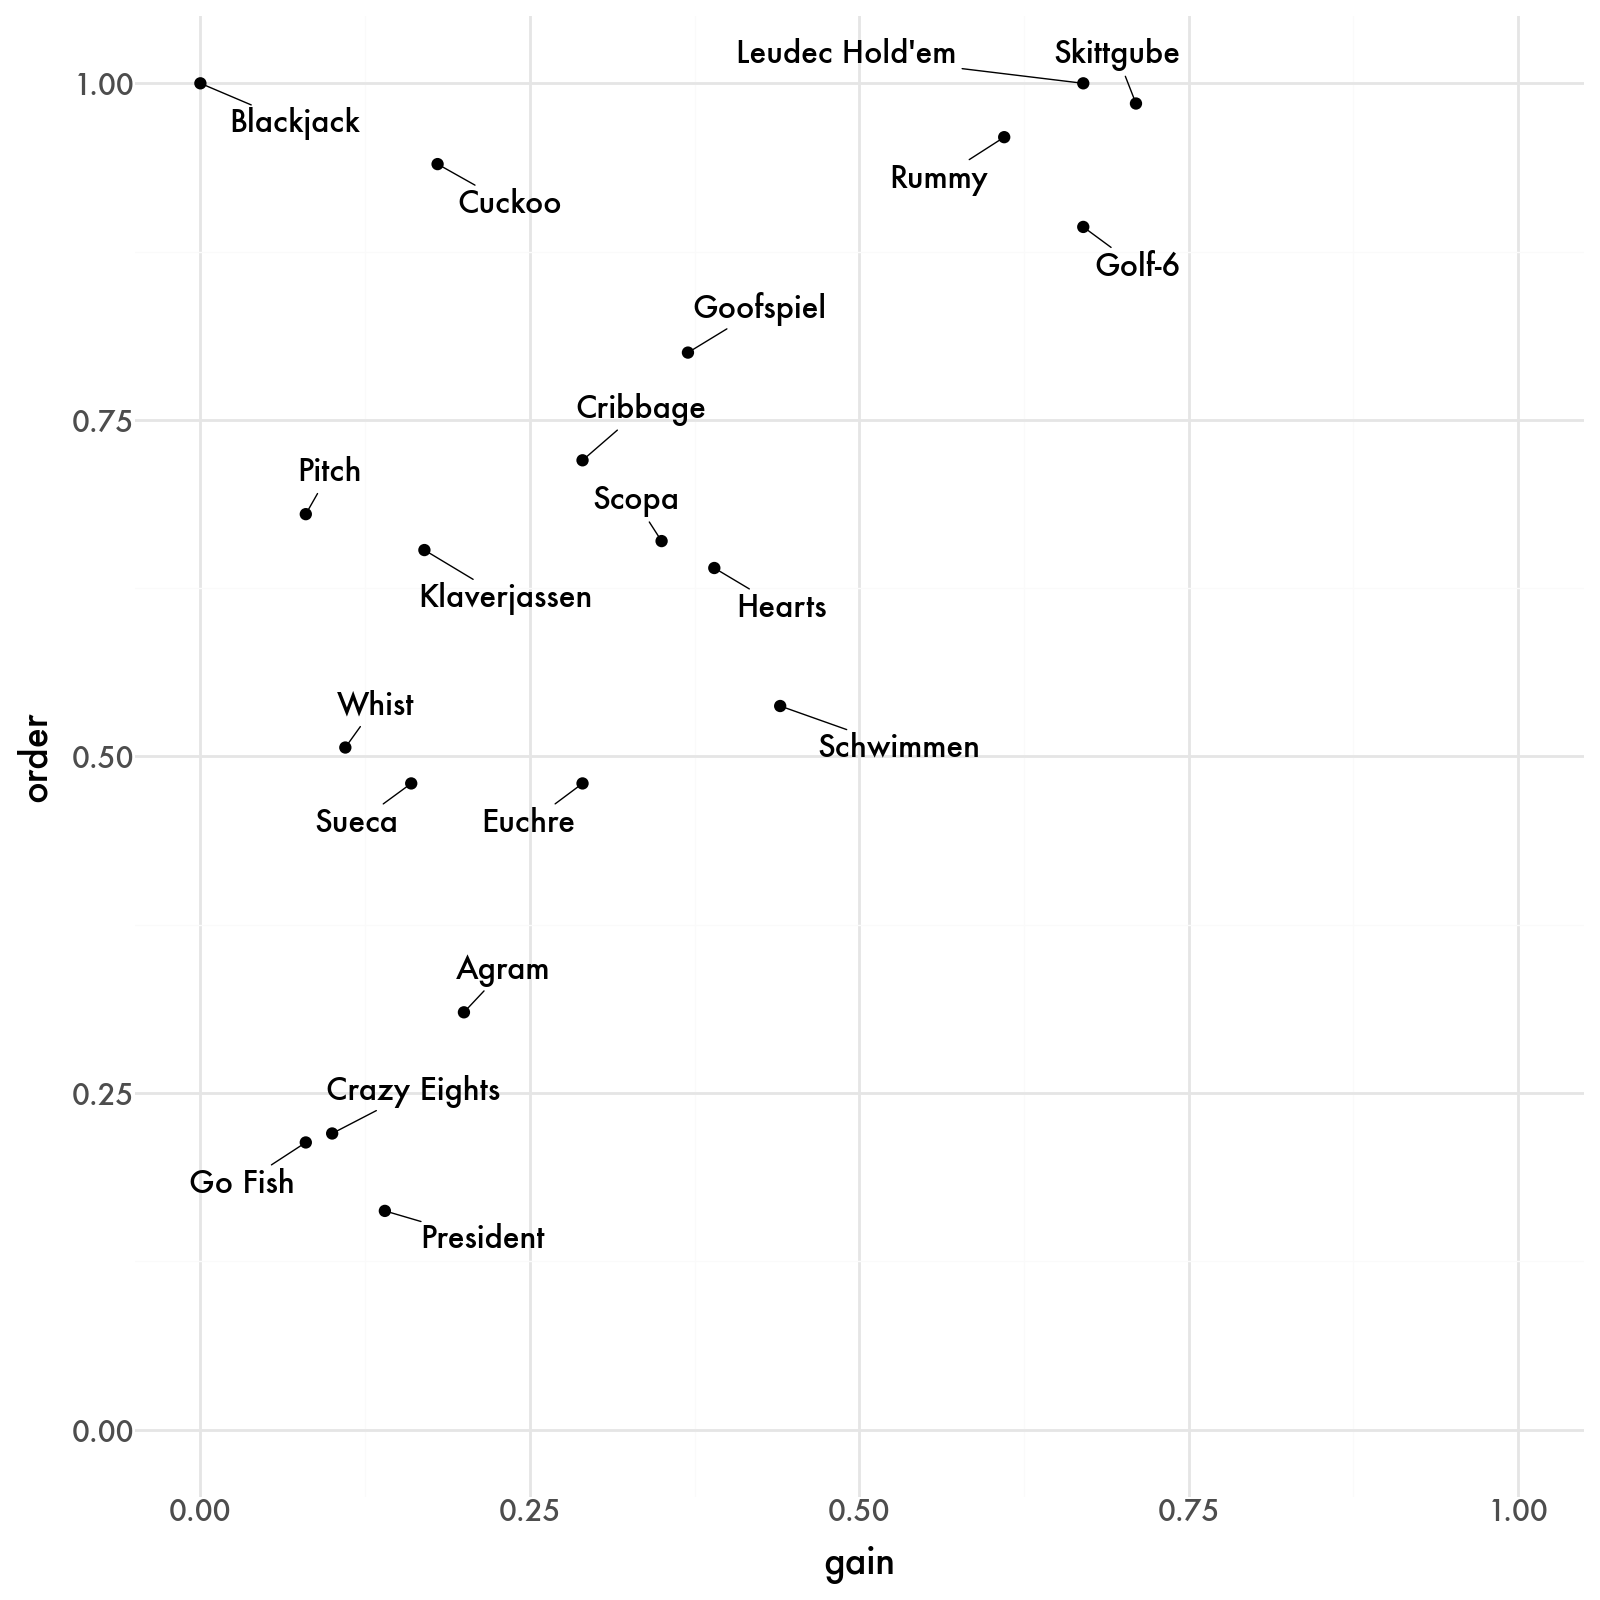

In [110]:
(ggplot(gameframe, aes("gain", "order", label="name"))
 + geom_point()
 + xlim(0, 1)
 + ylim(0, 1)
 + geom_text(adjust_text={"arrowprops": {"arrowstyle": "-"}})
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(figure_size=(8, 8))
)

In [111]:
rf6 = rf3.merge(gameframe[["game", "name", "gain", "player"]], on='game', how='left')
rf6.sort_values(by=['gain'])

,game,ai,run,name,gain,player
2,Blackjack,PIMC,1.00,Blackjack,0.00,1
3,Blackjack,Random,1.00,Blackjack,0.00,1
15,GoFish,Random,0.33,Go Fish,0.08,4
14,GoFish,PIMC,0.41,Go Fish,0.08,4
24,Pitch,PIMC,0.76,Pitch,0.08,4
25,Pitch,Random,0.68,Pitch,0.08,4
4,CrazyEights,PIMC,0.48,Crazy Eights,0.10,3
5,CrazyEights,Random,0.38,Crazy Eights,0.10,3
39,Whist,Random,0.52,Whist,0.11,4
38,Whist,PIMC,0.63,Whist,0.11,4


/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 10 x 5 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Ranks.png


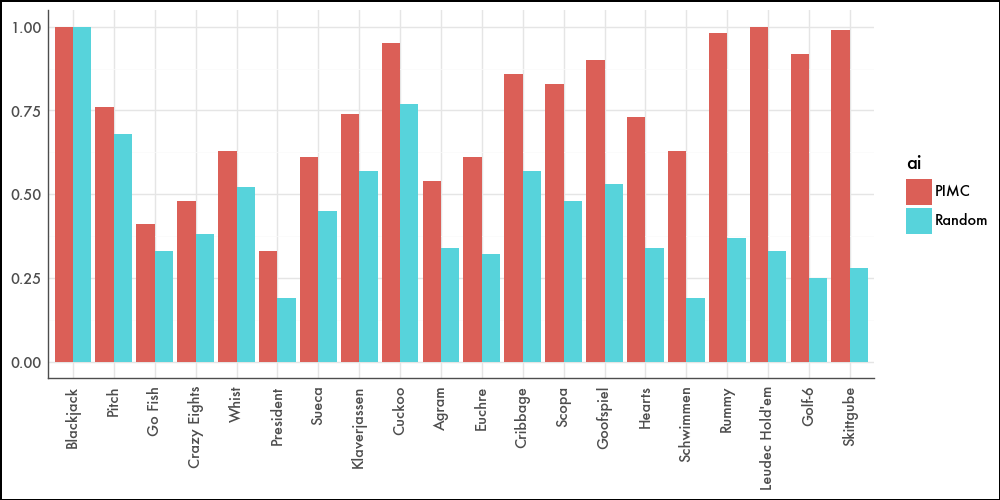

In [112]:
rplot = (ggplot(rf6, aes('reorder(name, gain)', "run", fill="ai"))
 + geom_bar(position="dodge", stat="identity")
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(figure_size=(10, 5))
 + theme(
        axis_text_x=element_text(rotation=90),
        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        axis_title=element_blank(),
        panel_spacing=0.03,
    )
 + ylim(0, 1)
 + labs(x='player', y='rank')
)
rplot.save("Ranks.png")
rplot.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 14 x 14 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: AIBarRanks.png


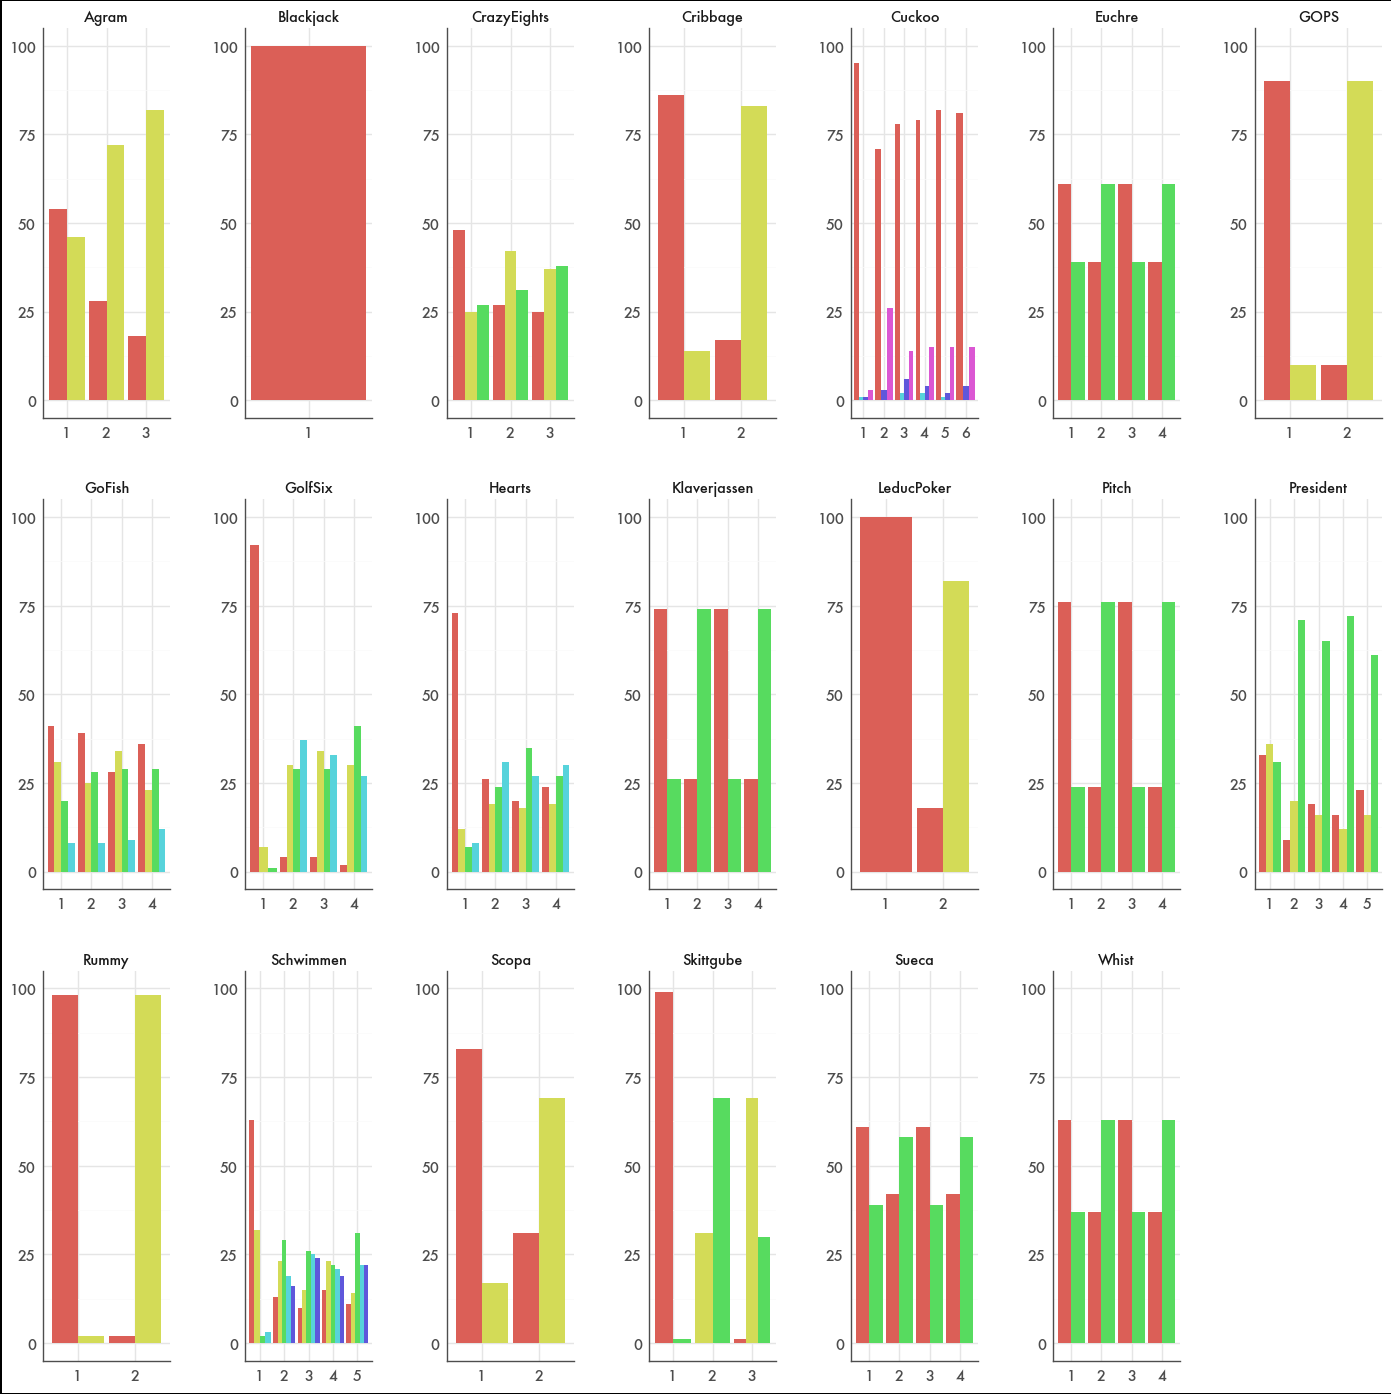

In [113]:
rplot = (ggplot(rf2[rf2["ai"]=="PIMC"], aes("player", "run", fill="rank"))
 + geom_bar(position="dodge", stat="identity")
 + facet_wrap("game", scales = "free", ncol=7)
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(legend_position='none', figure_size=(14, 14))
 + theme(
        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        axis_title=element_blank(),
        panel_spacing=0.03,
    )
 + ylim(0, 100)
 + labs(x='player', y='rank')
)
rplot.save("AIBarRanks.png")
rplot.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 10 x 8 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: RandomScores.png


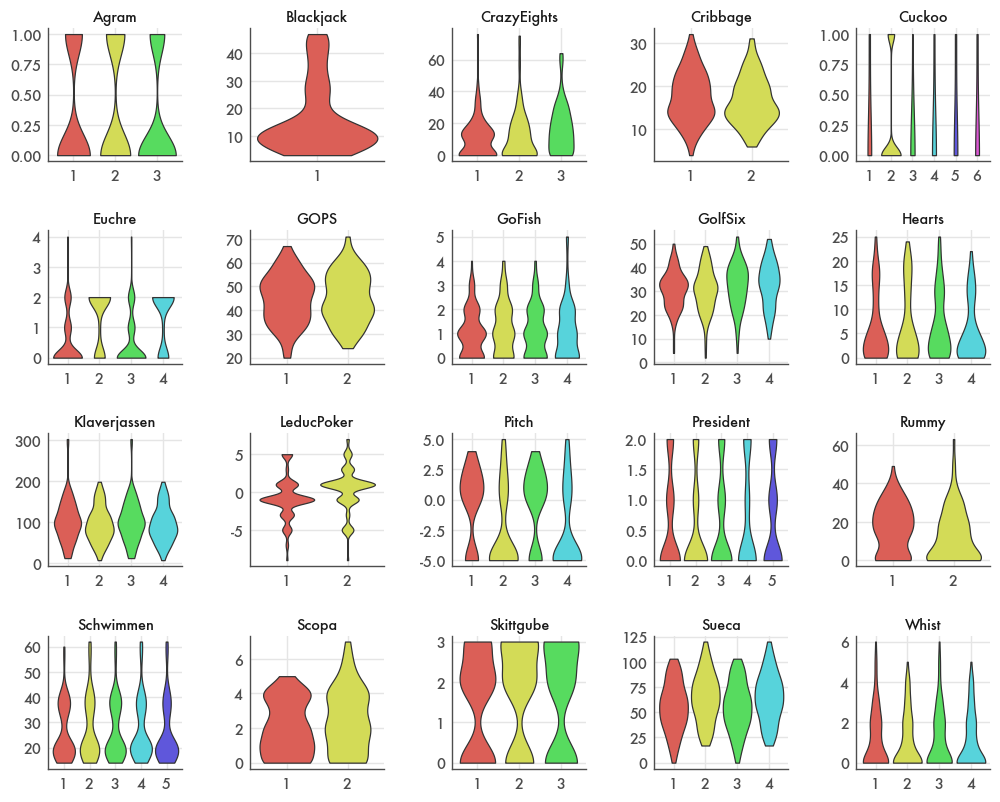

In [114]:
splot = (ggplot(resultsframe[resultsframe["ai"].str.startswith("R")], aes("player", "score", fill="player"))
 + geom_violin()
 + facet_wrap("game", scales = "free", ncol=5)
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(legend_position='none', figure_size=(10, 8))
 + theme(
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        axis_title=element_blank(),
        panel_spacing=0.03,
    )
 + labs(x='player', y='rank')
 + scale_y_continuous(minor_breaks=False)
)
splot.save("RandomScores.png")
splot.show()

In [115]:
rf2 = resultsframe[resultsframe["ai"].str.startswith("P")].groupby(['game', 'player', 'rank'], as_index=False).count()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 14 x 14 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: AIRanks.png


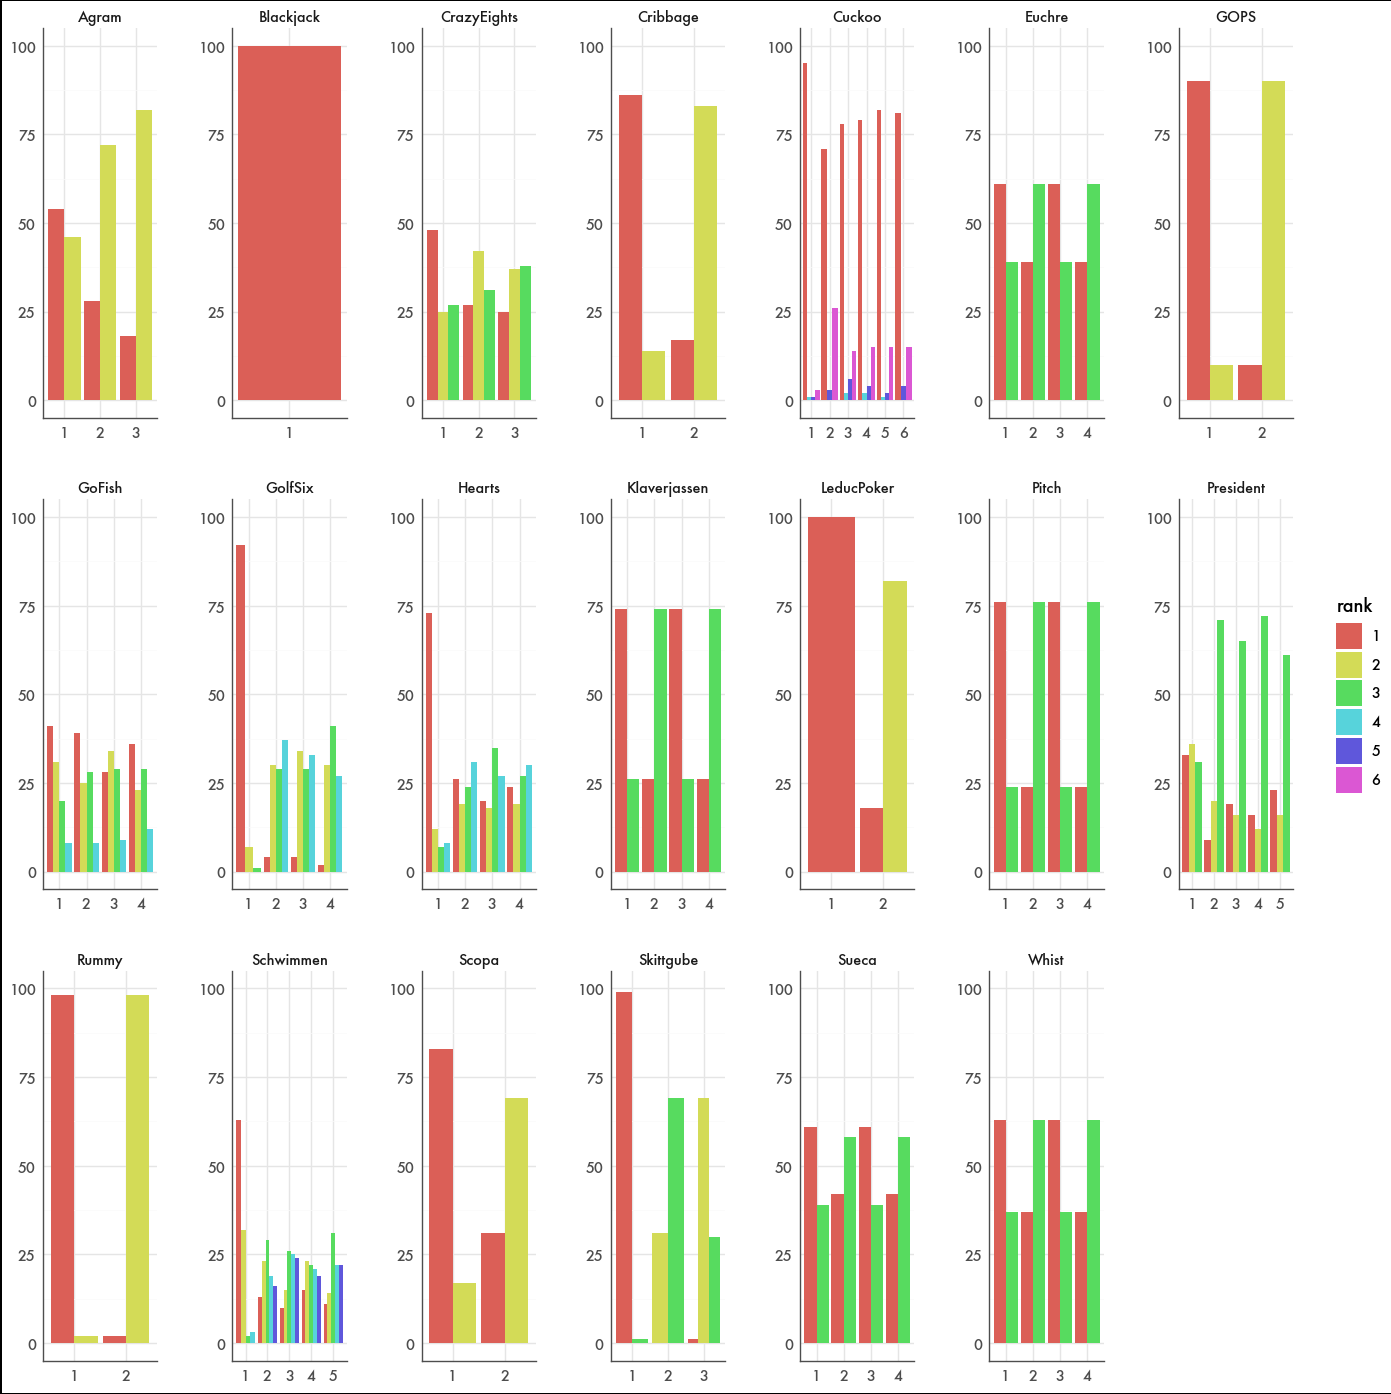

In [116]:
rplot = (ggplot(rf2, aes("player", "run", fill="rank"))
 + geom_bar(position="dodge", stat="identity")
 + facet_wrap("game", scales = "free", ncol=7)
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(figure_size=(14, 14))
 + ylim(0, 100)
 + theme(
        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        axis_title=element_blank(),
        panel_spacing=0.03,
    )
 + labs(x='player', y='rank')
)
rplot.save("AIRanks.png")
rplot.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 10 x 20 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: AllScores.png


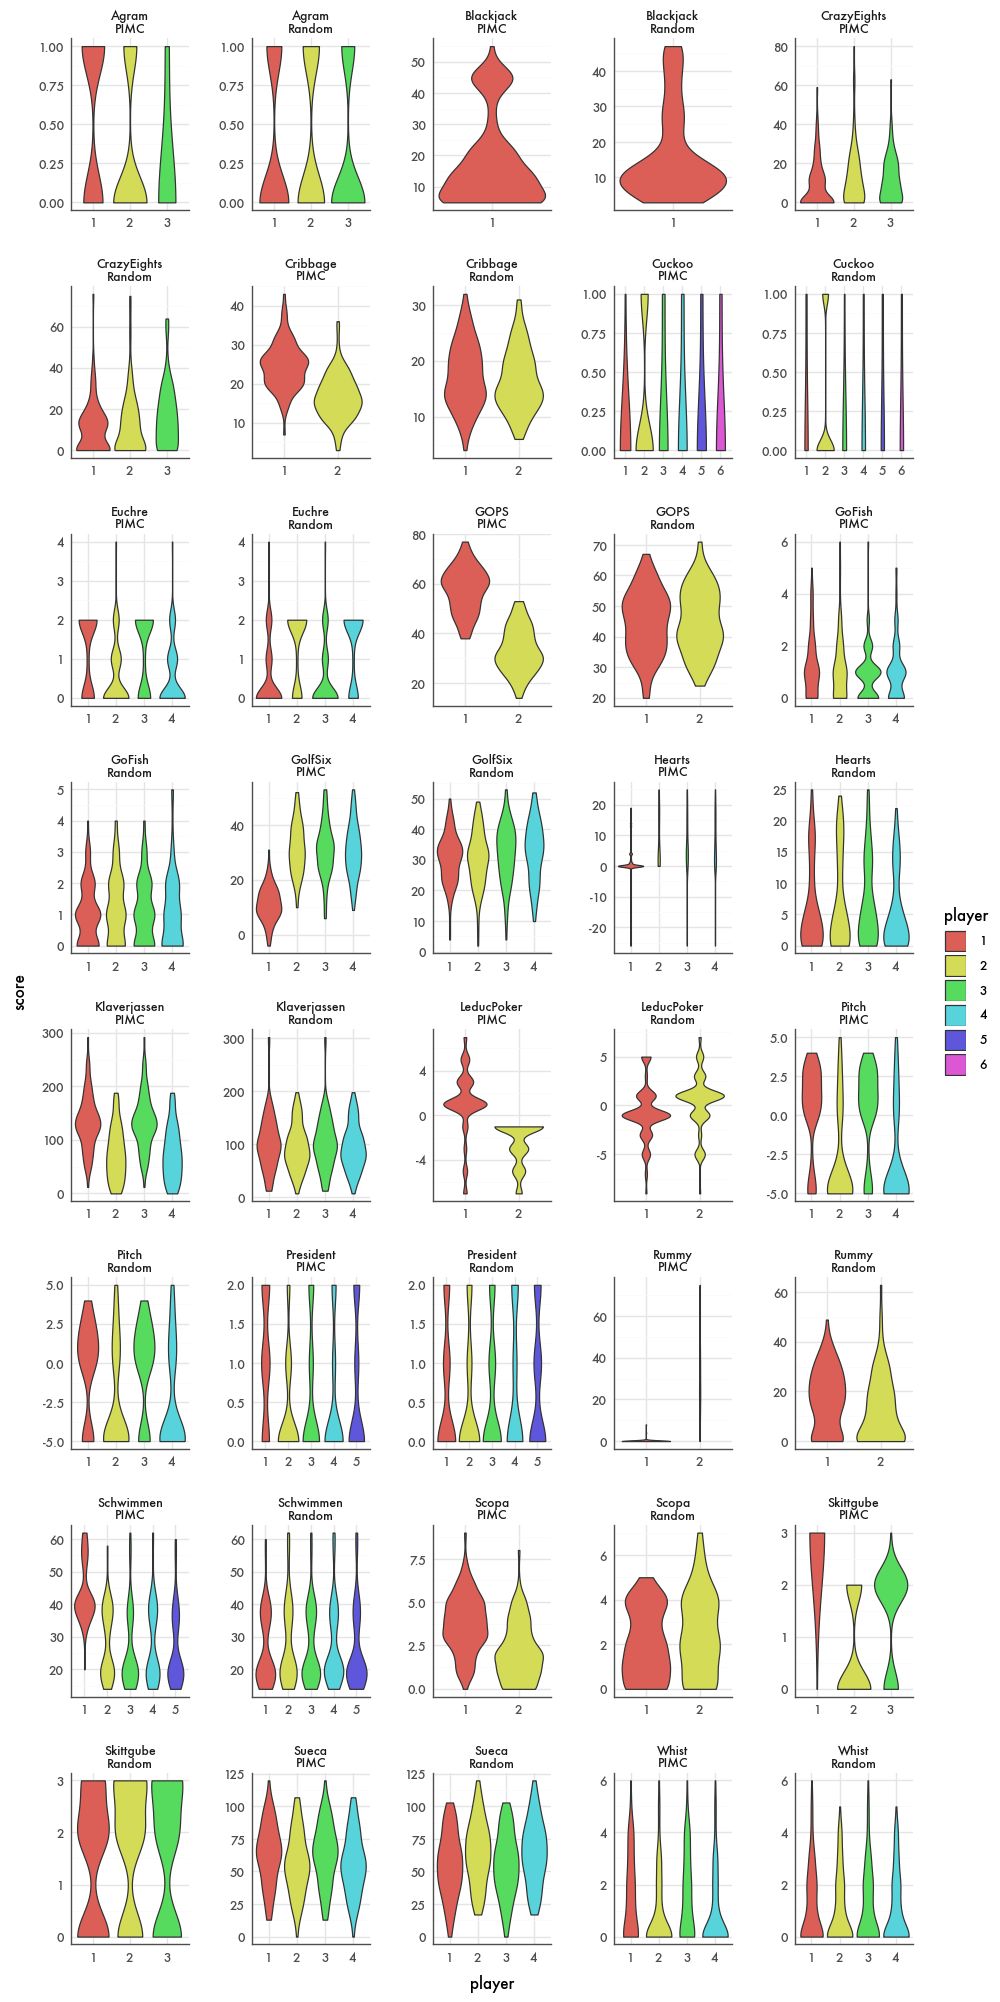

In [117]:
splot = (ggplot(resultsframe, aes("player", "score", fill="player"))
 + geom_violin()
 + facet_wrap(["game", "ai"], scales = "free", ncol = 5)
 + theme_minimal(base_family="Futura", base_size=11)
 + theme(figure_size=(10, 20))
 + theme(
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        panel_spacing=0.03,
    )
 + labs(x='player', y='score')
)
splot.save("AllScores.png")
splot.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 10 x 8 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: PvsRScores.png


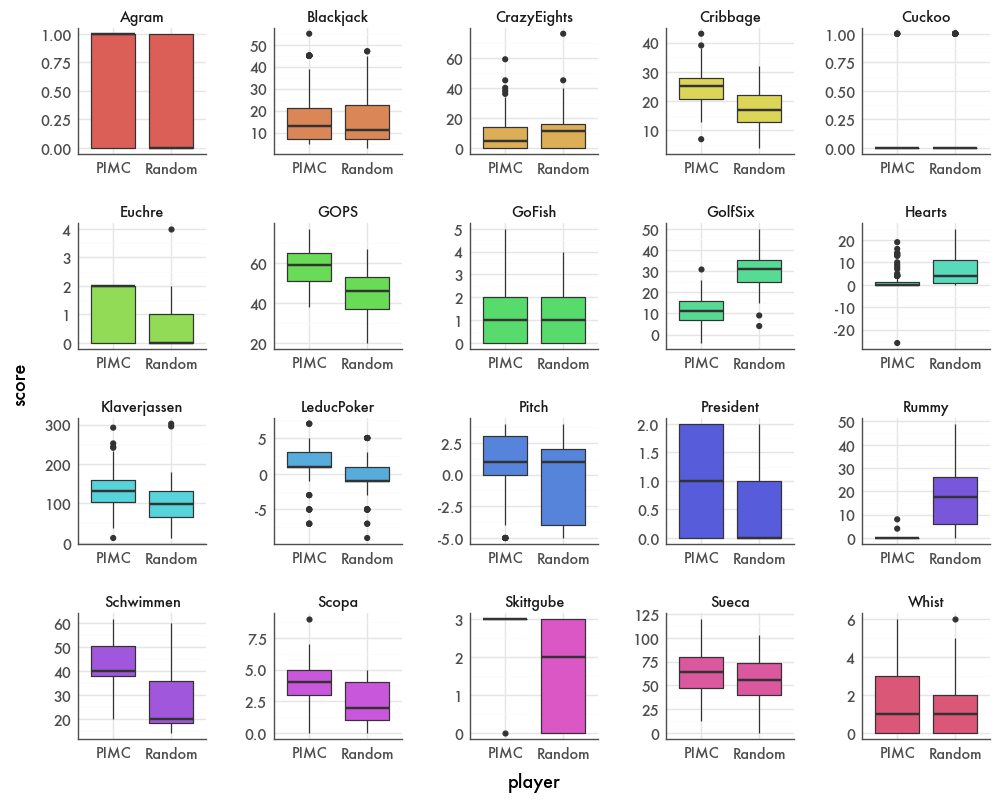

In [118]:
resultsframe["rank"] = resultsframe["rank"].astype(int)

splot = (ggplot(resultsframe[resultsframe["player"]=="1"], aes("ai", "score", fill="game"))
 + geom_boxplot()
 + facet_wrap("game", scales = "free", ncol=5)
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(legend_position='none', figure_size=(10, 8))
 + theme(
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        panel_spacing=0.03,
    )
 + labs(x='player', y='score')
)
splot.save("PvsRScores.png")
splot.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 10 x 8 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: PvsRScores.png


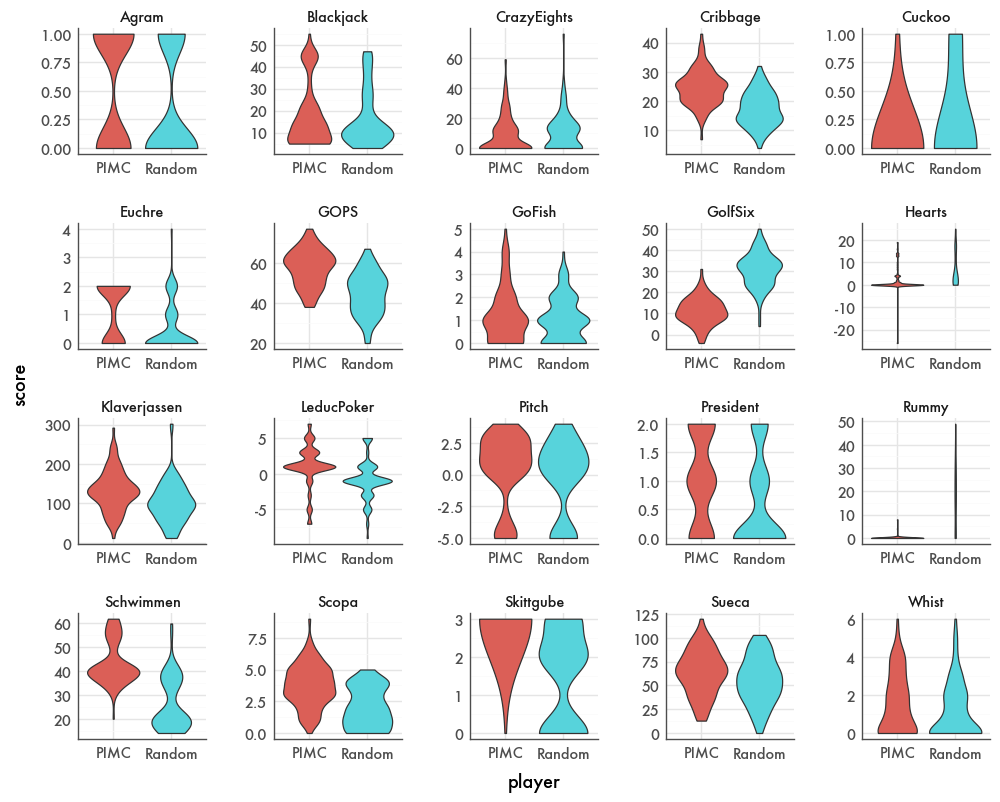

In [131]:
resultsframe["rank"] = resultsframe["rank"].astype(int)

splot = (ggplot(resultsframe[resultsframe["player"]=="1"], aes("ai", "score", fill="ai"))
 + geom_violin()
 + facet_wrap("game", scales = "free", ncol=5)
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(legend_position='none', figure_size=(10, 8))
 + theme(
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        panel_spacing=0.03,
    )
 + labs(x='player', y='score')
)
splot.save("PvsRScores.png")
splot.show()

In [120]:
def sig_code(pval):
    if pval < 0.001:
        return "***"
    elif pval < 0.01:
        return "**"
    elif pval < 0.05:
        return "*"
    elif pval < 0.1:
        return "."
    else:
        return ""
comp = resultsframe[resultsframe["player"]=="1"][["game", "ai", "run", "score"]]
comp = comp.pivot(index=["game", "run"], columns="ai", values="score")
comp2 = comp.groupby("game").apply(lambda df: st.ttest_ind(df['PIMC'], df['Random'])[1]).reset_index().rename(columns={0:"p-value"})[["game", "p-value"]]
comp3 = comp.groupby('game').apply(lambda df: sig_code(st.ttest_ind(df['PIMC'], df['Random'])[1])).reset_index().rename(columns={0:"significance"})
comp4 = comp3.merge(comp2, on="game", how="left").sort_values(by="p-value")
comp4

,game,significance,p-value
8,GolfSix,***,7.445657e-46
14,Rummy,***,1.318596e-29
15,Schwimmen,***,4.731498e-26
17,Skittgube,***,9.310092e-24
6,GOPS,***,3.103471e-17
3,Cribbage,***,1.698576e-15
16,Scopa,***,2.756543e-12
5,Euchre,***,3.303755e-07
9,Hearts,***,3.485981e-07
11,LeducPoker,***,6.263617e-06


# Spread

In [121]:
first = True
for index, row in gameframe.iterrows():
    if row["game"] != "Blackjack":
        gf = pd.read_csv(row["fileprefix"] + row["game"] + "/" + str(row["player"]) + "/" + "P" + "R" * (row["player"] - 1) + "/spread.csv")
        gf["game"] = row["game"]
        if row["game"] == "Schwimmen":
            gf["spread"] = gf["spread"] / 2.0
        if first:
            spreadframe = gf
            first = False
        else:
            spreadframe = pd.concat([spreadframe, gf])
spreadframe["player"] = spreadframe["player"].astype(str)
spreadframe["run"] = spreadframe["run"].astype(str)

In [122]:
spreadframe

,game,numPlayers,ai,run,pmove,player,spread
0,Agram,3,PRR,1,1,0,0.142
1,Agram,3,PRR,1,2,0,0.093
2,Agram,3,PRR,1,3,0,0.025
3,Agram,3,PRR,1,4,0,0.169
4,Agram,3,PRR,1,5,0,0.054
...,...,...,...,...,...,...,...
1295,Whist,4,PRRR,100,9,0,0.000
1296,Whist,4,PRRR,100,10,0,0.000
1297,Whist,4,PRRR,100,11,0,0.000
1298,Whist,4,PRRR,100,12,0,0.000


/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 14 x 7 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Spread.png


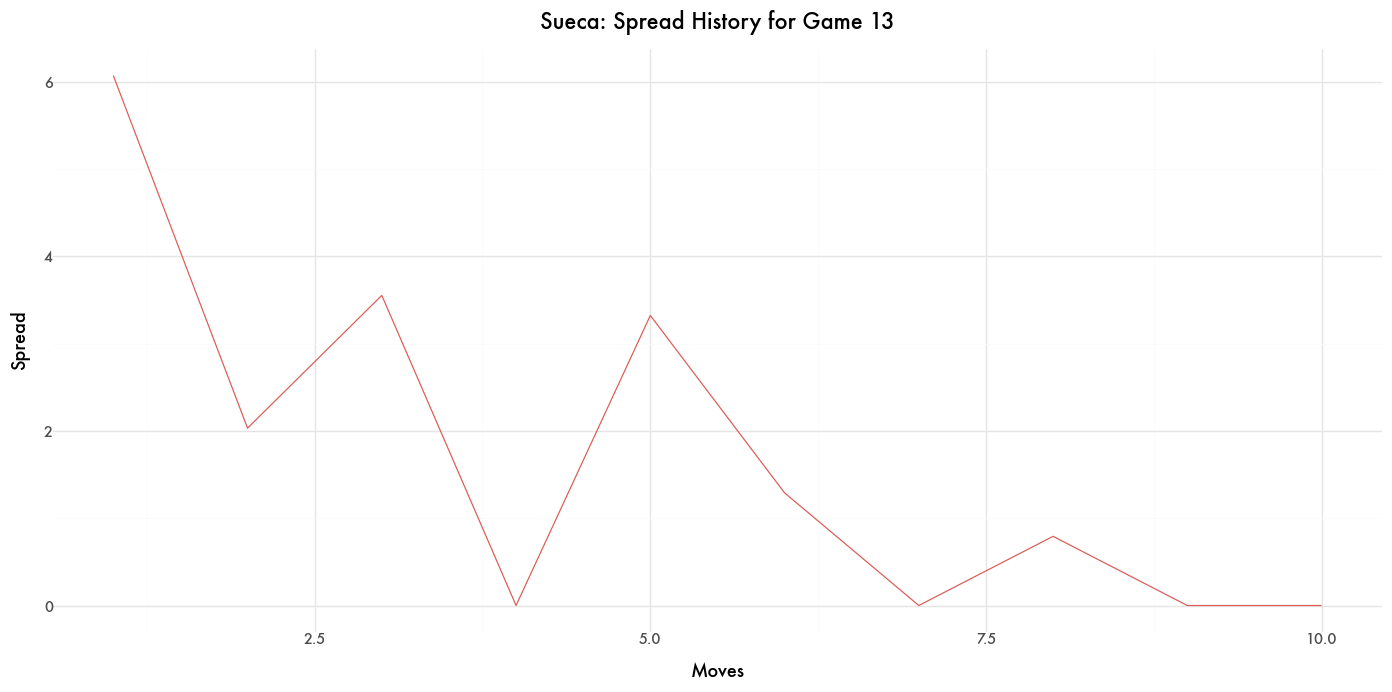

In [124]:
game = "Sueca"
iter = "13"
splot = (ggplot(spreadframe[(spreadframe["run"] == iter) & (spreadframe["game"] == game)], 
       aes(x="pmove", y="spread", color="player"))
 + geom_line()
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(legend_position='none', figure_size=(14, 7))
 + labs(x='Moves', y='Spread', title=game + ": Spread History for Game " + str(iter))
)
splot.save("Spread.png")
splot.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 14 x 7 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Spread.png


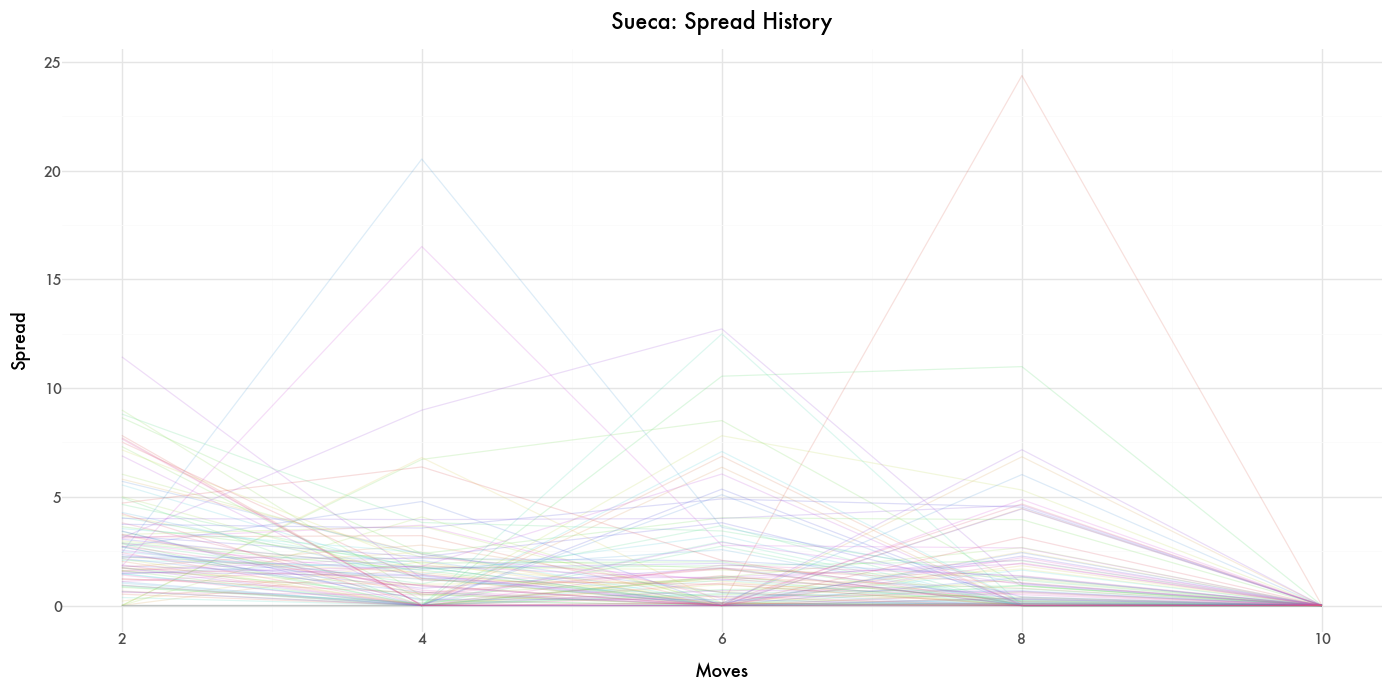

In [125]:
splot = (ggplot(spreadframe[(spreadframe["game"] == game) & (spreadframe["pmove"]%2 == 0)], 
       aes(x="pmove", y="spread", color="run"))
 + geom_line(alpha=0.2)
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(legend_position='none', figure_size=(14, 7))
 + labs(x='Moves', y='Spread', title=game + ": Spread History")
)
splot.save("Spread.png")
splot.show()

In [126]:
spreadframe[(spreadframe["game"] == game)]

,game,numPlayers,ai,run,pmove,player,spread
0,Sueca,4,PRRR,1,1,0,5.871
1,Sueca,4,PRRR,1,2,0,7.821
2,Sueca,4,PRRR,1,3,0,1.106
3,Sueca,4,PRRR,1,4,0,0.000
4,Sueca,4,PRRR,1,5,0,1.146
...,...,...,...,...,...,...,...
995,Sueca,4,PRRR,100,6,0,1.376
996,Sueca,4,PRRR,100,7,0,0.552
997,Sueca,4,PRRR,100,8,0,0.195
998,Sueca,4,PRRR,100,9,0,0.024


/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 10 x 8 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Spread.png
/opt/anaconda3/lib/python3.13/site-packages/plotnine/geoms/geom_path.py:113: PlotnineWarning: geom_path: Each group consist of only one observation. Do you need to adjust the group aesthetic?
/opt/anaconda3/lib/python3.13/site-packages/plotnine/geoms/geom_path.py:113: PlotnineWarning: geom_path: Each group consist of only one observation. Do you need to adjust the group aesthetic?


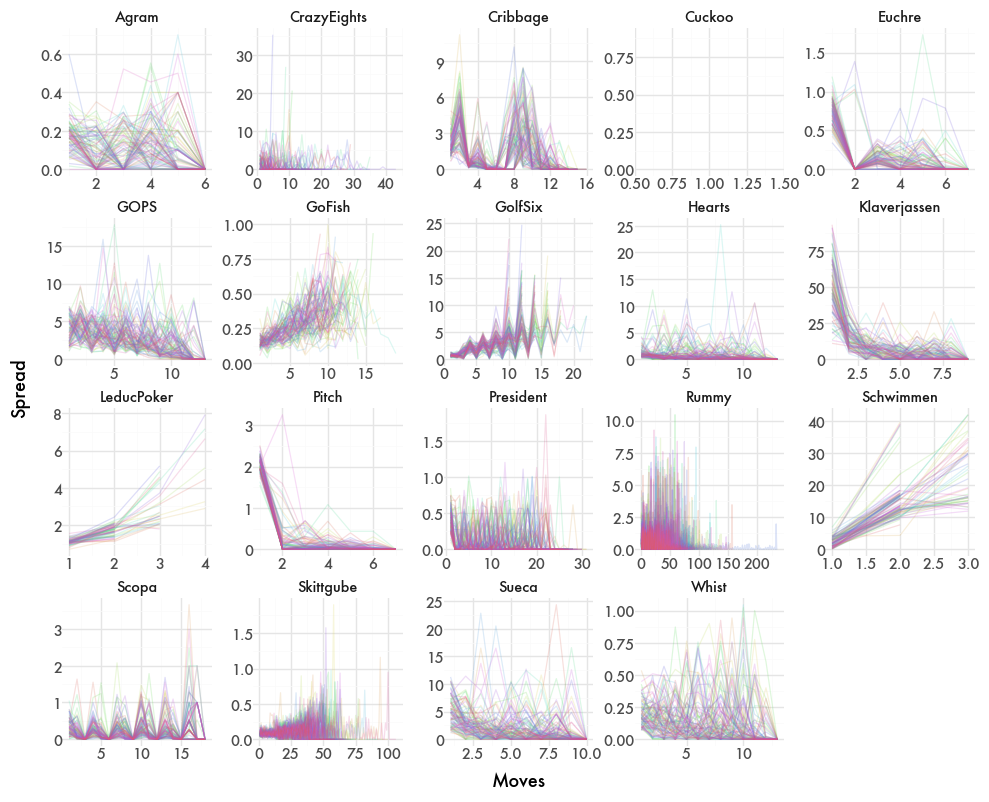

In [129]:
splot = (ggplot(spreadframe, 
       aes(x="pmove", y="spread", color="run"))
 + geom_line(alpha=0.2)
 + facet_wrap("game", scales = "free", ncol=5)
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(legend_position='none', figure_size=(10, 8))
 + labs(x='Moves', y='Spread')
)
splot.save("Spread.png")
splot.show()

# Lead History 

First, we create the Dataframe for storing all of the game statistics for the lead histories, then we can use this to project multiple graphs.

The **Security** and **Drama** Heuristics are calculated as part of this process.

In [61]:
first = True
for index, row in gameframe.iterrows():
    if row["game"] != "Blackjack" and row["game"] != "GoFish" and row["game"] != "Rummy" and row["game"] != "Skittgube":
        #gf = pd.read_csv(row["fileprefix"] + row["game"] + "/" + str(row["player"]) + "/" + "P" + "R" * (row["player"] - 1) + "/lead.csv")
        gf = pd.read_csv(fileprefix + row["game"] + "/" + str(row["player"]) + "/" + "PPPPPP" + "/lead.csv")
        gf["game"] = row["game"]
        if first:
            leadframe = gf
            first = False
        else:
            leadframe = pd.concat([leadframe, gf])
leadframe

,game,numPlayers,ai,run,move,recorder,player,score,rank,rankestimate
0,Agram,3,PPPPPP,1,1,1,1,0.76,1,0.880000
1,Agram,3,PPPPPP,1,1,1,2,0.12,3,0.560000
2,Agram,3,PPPPPP,1,1,1,3,0.12,2,0.560000
3,Agram,3,PPPPPP,1,2,2,1,0.42,1,0.710000
4,Agram,3,PPPPPP,1,2,2,2,0.26,3,0.630000
...,...,...,...,...,...,...,...,...,...,...
21195,Whist,4,PPPPPP,100,52,3,4,0.00,3,0.333333
21196,Whist,4,PPPPPP,100,53,1,1,2.00,2,1.000000
21197,Whist,4,PPPPPP,100,53,2,2,0.00,4,0.333333
21198,Whist,4,PPPPPP,100,53,3,3,2.00,1,1.000000


In [62]:
leadframe[(leadframe["game"]=="Rummy") & (leadframe["run"] == 1)]

,game,numPlayers,ai,run,move,recorder,player,score,rank,rankestimate


In [63]:
leadframe[leadframe['rank'].isnull()]

,game,numPlayers,ai,run,move,recorder,player,score,rank,rankestimate


In [64]:
first = True
for game in gameframe["game"]:
    if game != "Blackjack" and game != "GoFish" and game != "Rummy" and game != "Skittgube":
        print(game)
        pv = gameframe[gameframe["game"] == game]["player"].values[0]
        myl = leadframe[leadframe["game"] == game]
        for run in range(1, 101):
            for player in range(1, pv + 1):
                myl2 = myl[(myl["run"] == run)  & (myl["player"] == player)]
                x = myl2["rankestimate"]
                length = myl2["move"].max()
                px = [x / (length - 1) for x in range(length)]
                f = interp1d(px, x)
                xnew = np.linspace(0, 1, num=101)
                ynew = f(xnew)
                n = pd.DataFrame([xnew, ynew], index=["portion", "estimate"]).T
                n["game"] = game
                n["run"] = run
                n["player"] = player
                n["rank"] = myl2["rank"].values[0]
                if first:
                    leads = n
                    first = False
                else:
                    leads = pd.concat([leads, n])

Agram
CrazyEights
Cribbage
Cuckoo
Euchre
GolfSix
GOPS
Hearts
Klaverjassen
LeducPoker
Pitch
President
Schwimmen
Scopa
Sueca
Whist


In [65]:
leads

,portion,estimate,game,run,player,rank
0,0.00,0.880000,Agram,1,1,1
1,0.01,0.849400,Agram,1,1,1
2,0.02,0.818800,Agram,1,1,1
3,0.03,0.788200,Agram,1,1,1
4,0.04,0.757600,Agram,1,1,1
...,...,...,...,...,...,...
96,0.96,0.333333,Whist,100,4,3
97,0.97,0.333333,Whist,100,4,3
98,0.98,0.333333,Whist,100,4,3
99,0.99,0.333333,Whist,100,4,3


In [66]:
leads["player"] = leads["player"].astype(str)
leads["run"] = leads["run"].astype(str)
leads["rank"] = leads["rank"].astype(str)
leads[(leads["game"] == "Cuckoo") & (leads["run"] == "1")]

,portion,estimate,game,run,player,rank
0,0.00,1.00000,Cuckoo,1,1,1
1,0.01,0.99616,Cuckoo,1,1,1
2,0.02,0.99232,Cuckoo,1,1,1
3,0.03,0.98848,Cuckoo,1,1,1
4,0.04,0.98464,Cuckoo,1,1,1
...,...,...,...,...,...,...
96,0.96,1.00000,Cuckoo,1,6,5
97,0.97,1.00000,Cuckoo,1,6,5
98,0.98,1.00000,Cuckoo,1,6,5
99,0.99,1.00000,Cuckoo,1,6,5


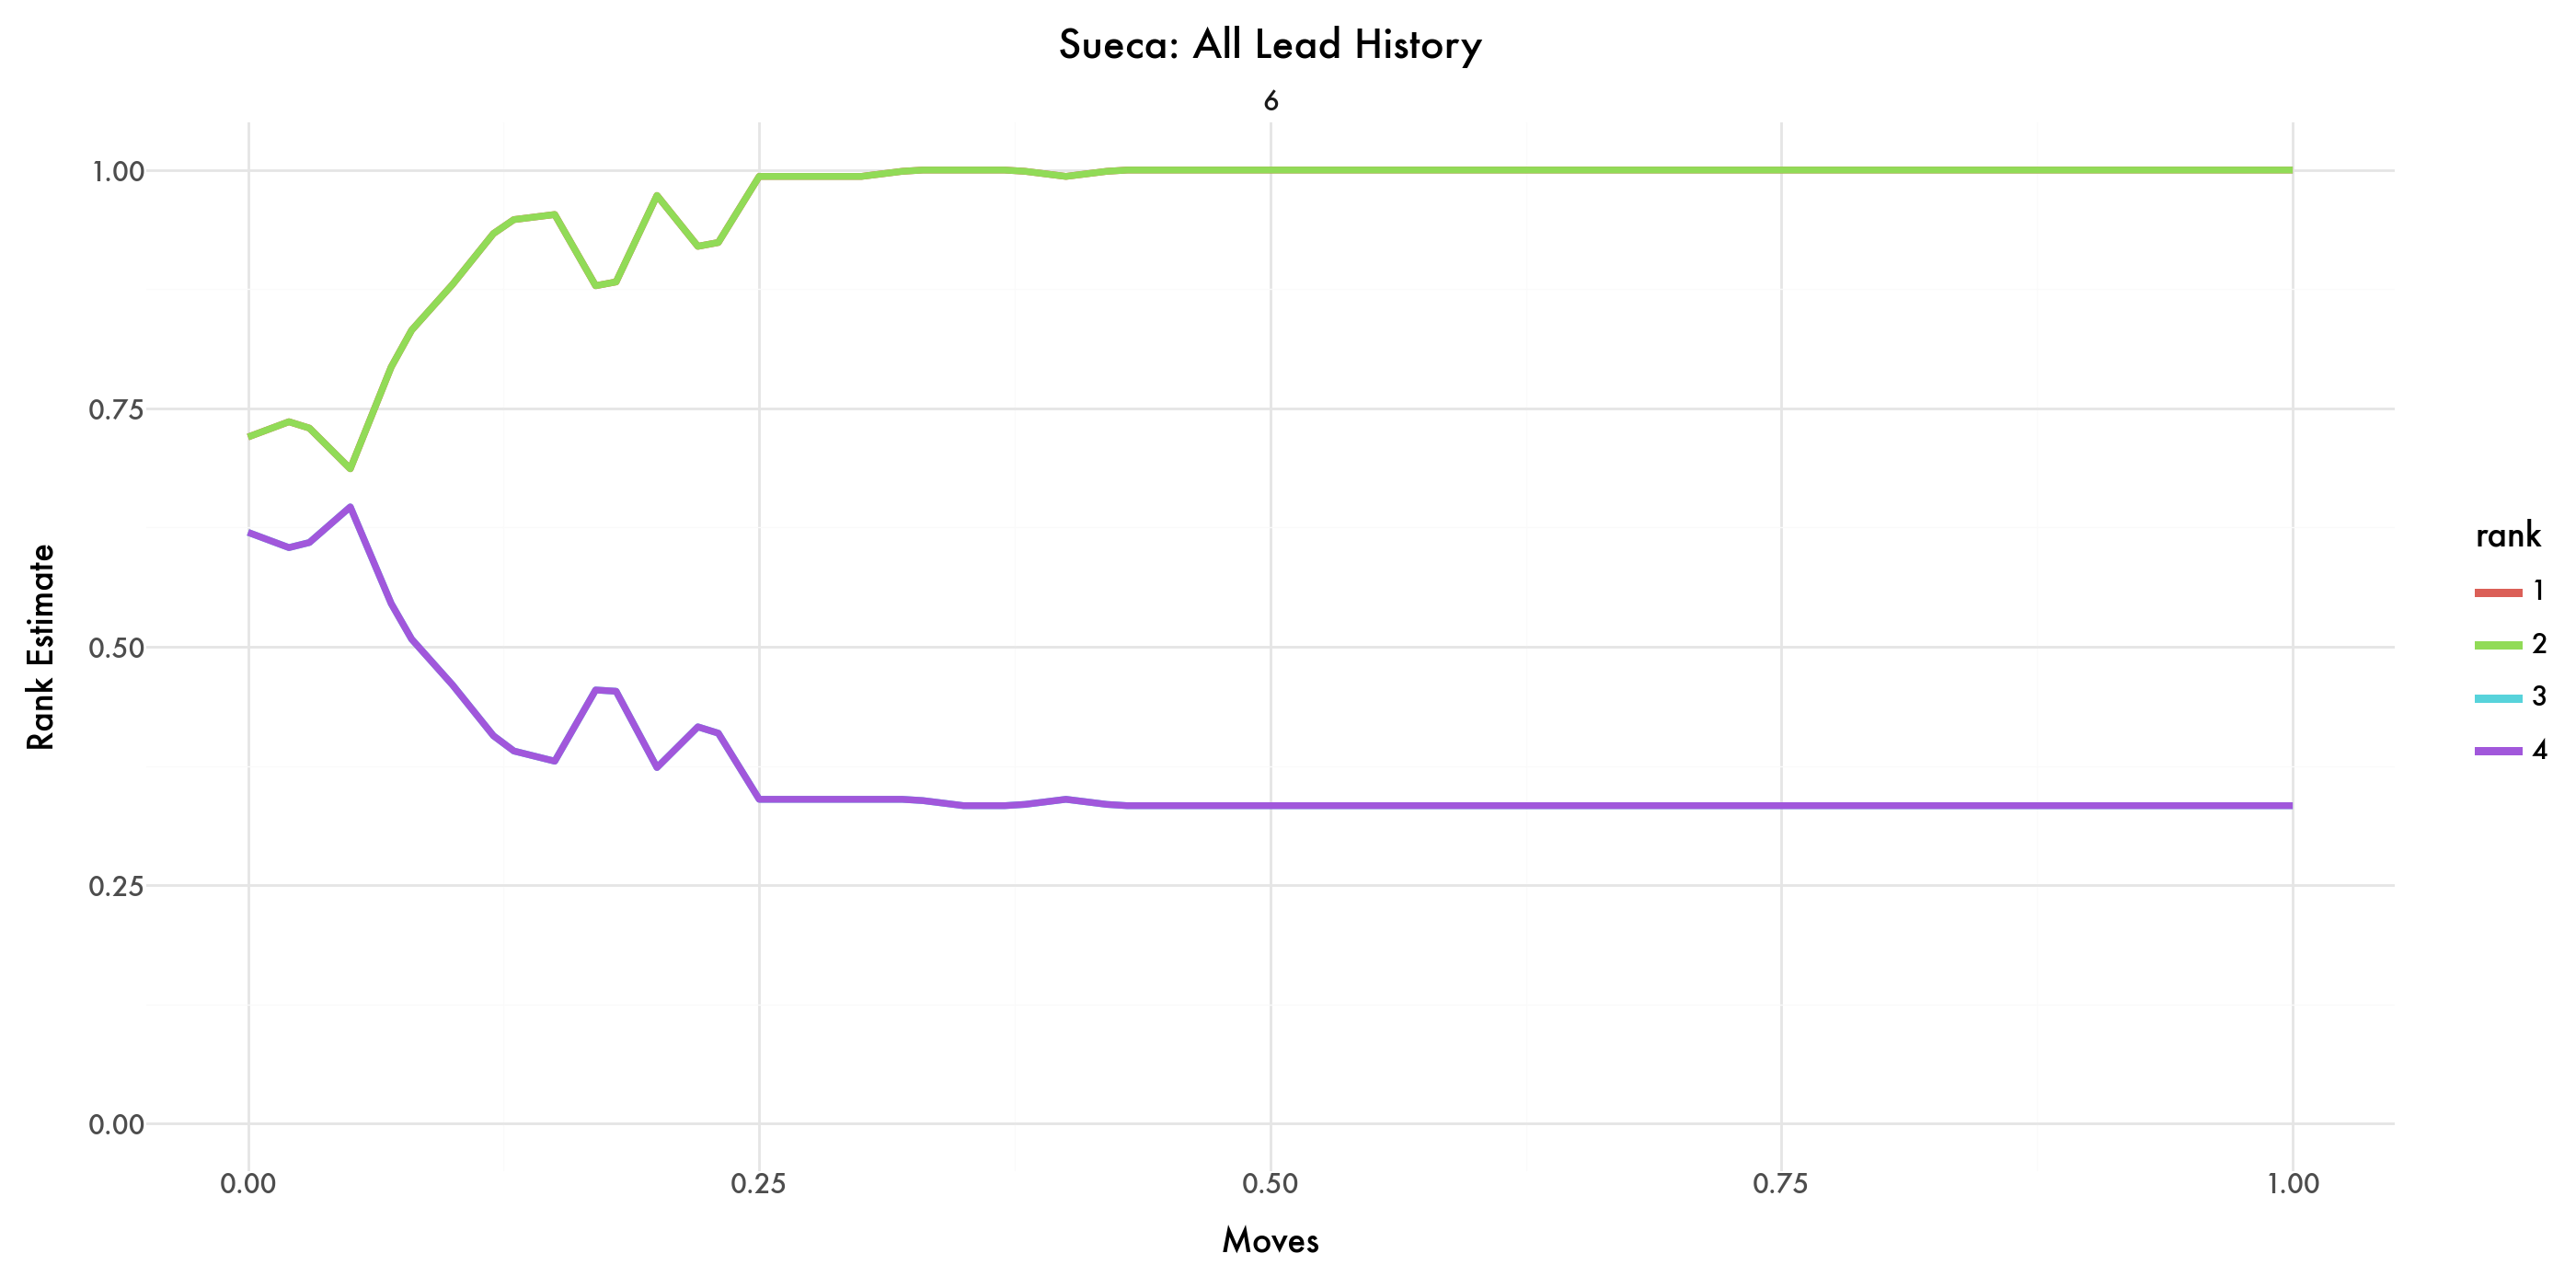

In [68]:
game = "Sueca"
iter="6"
(ggplot(leads[(leads["game"] == game) & (leads["run"]== iter)], 
       aes(x="portion", y="estimate", color="rank"))
 + geom_line(size=1.5)
 + ylim(0, 1)
 + facet_wrap("run", scales = "free_x")
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(figure_size=(14, 7))
 + labs(x='Moves', y='Rank Estimate', title=game + ": All Lead History")
)

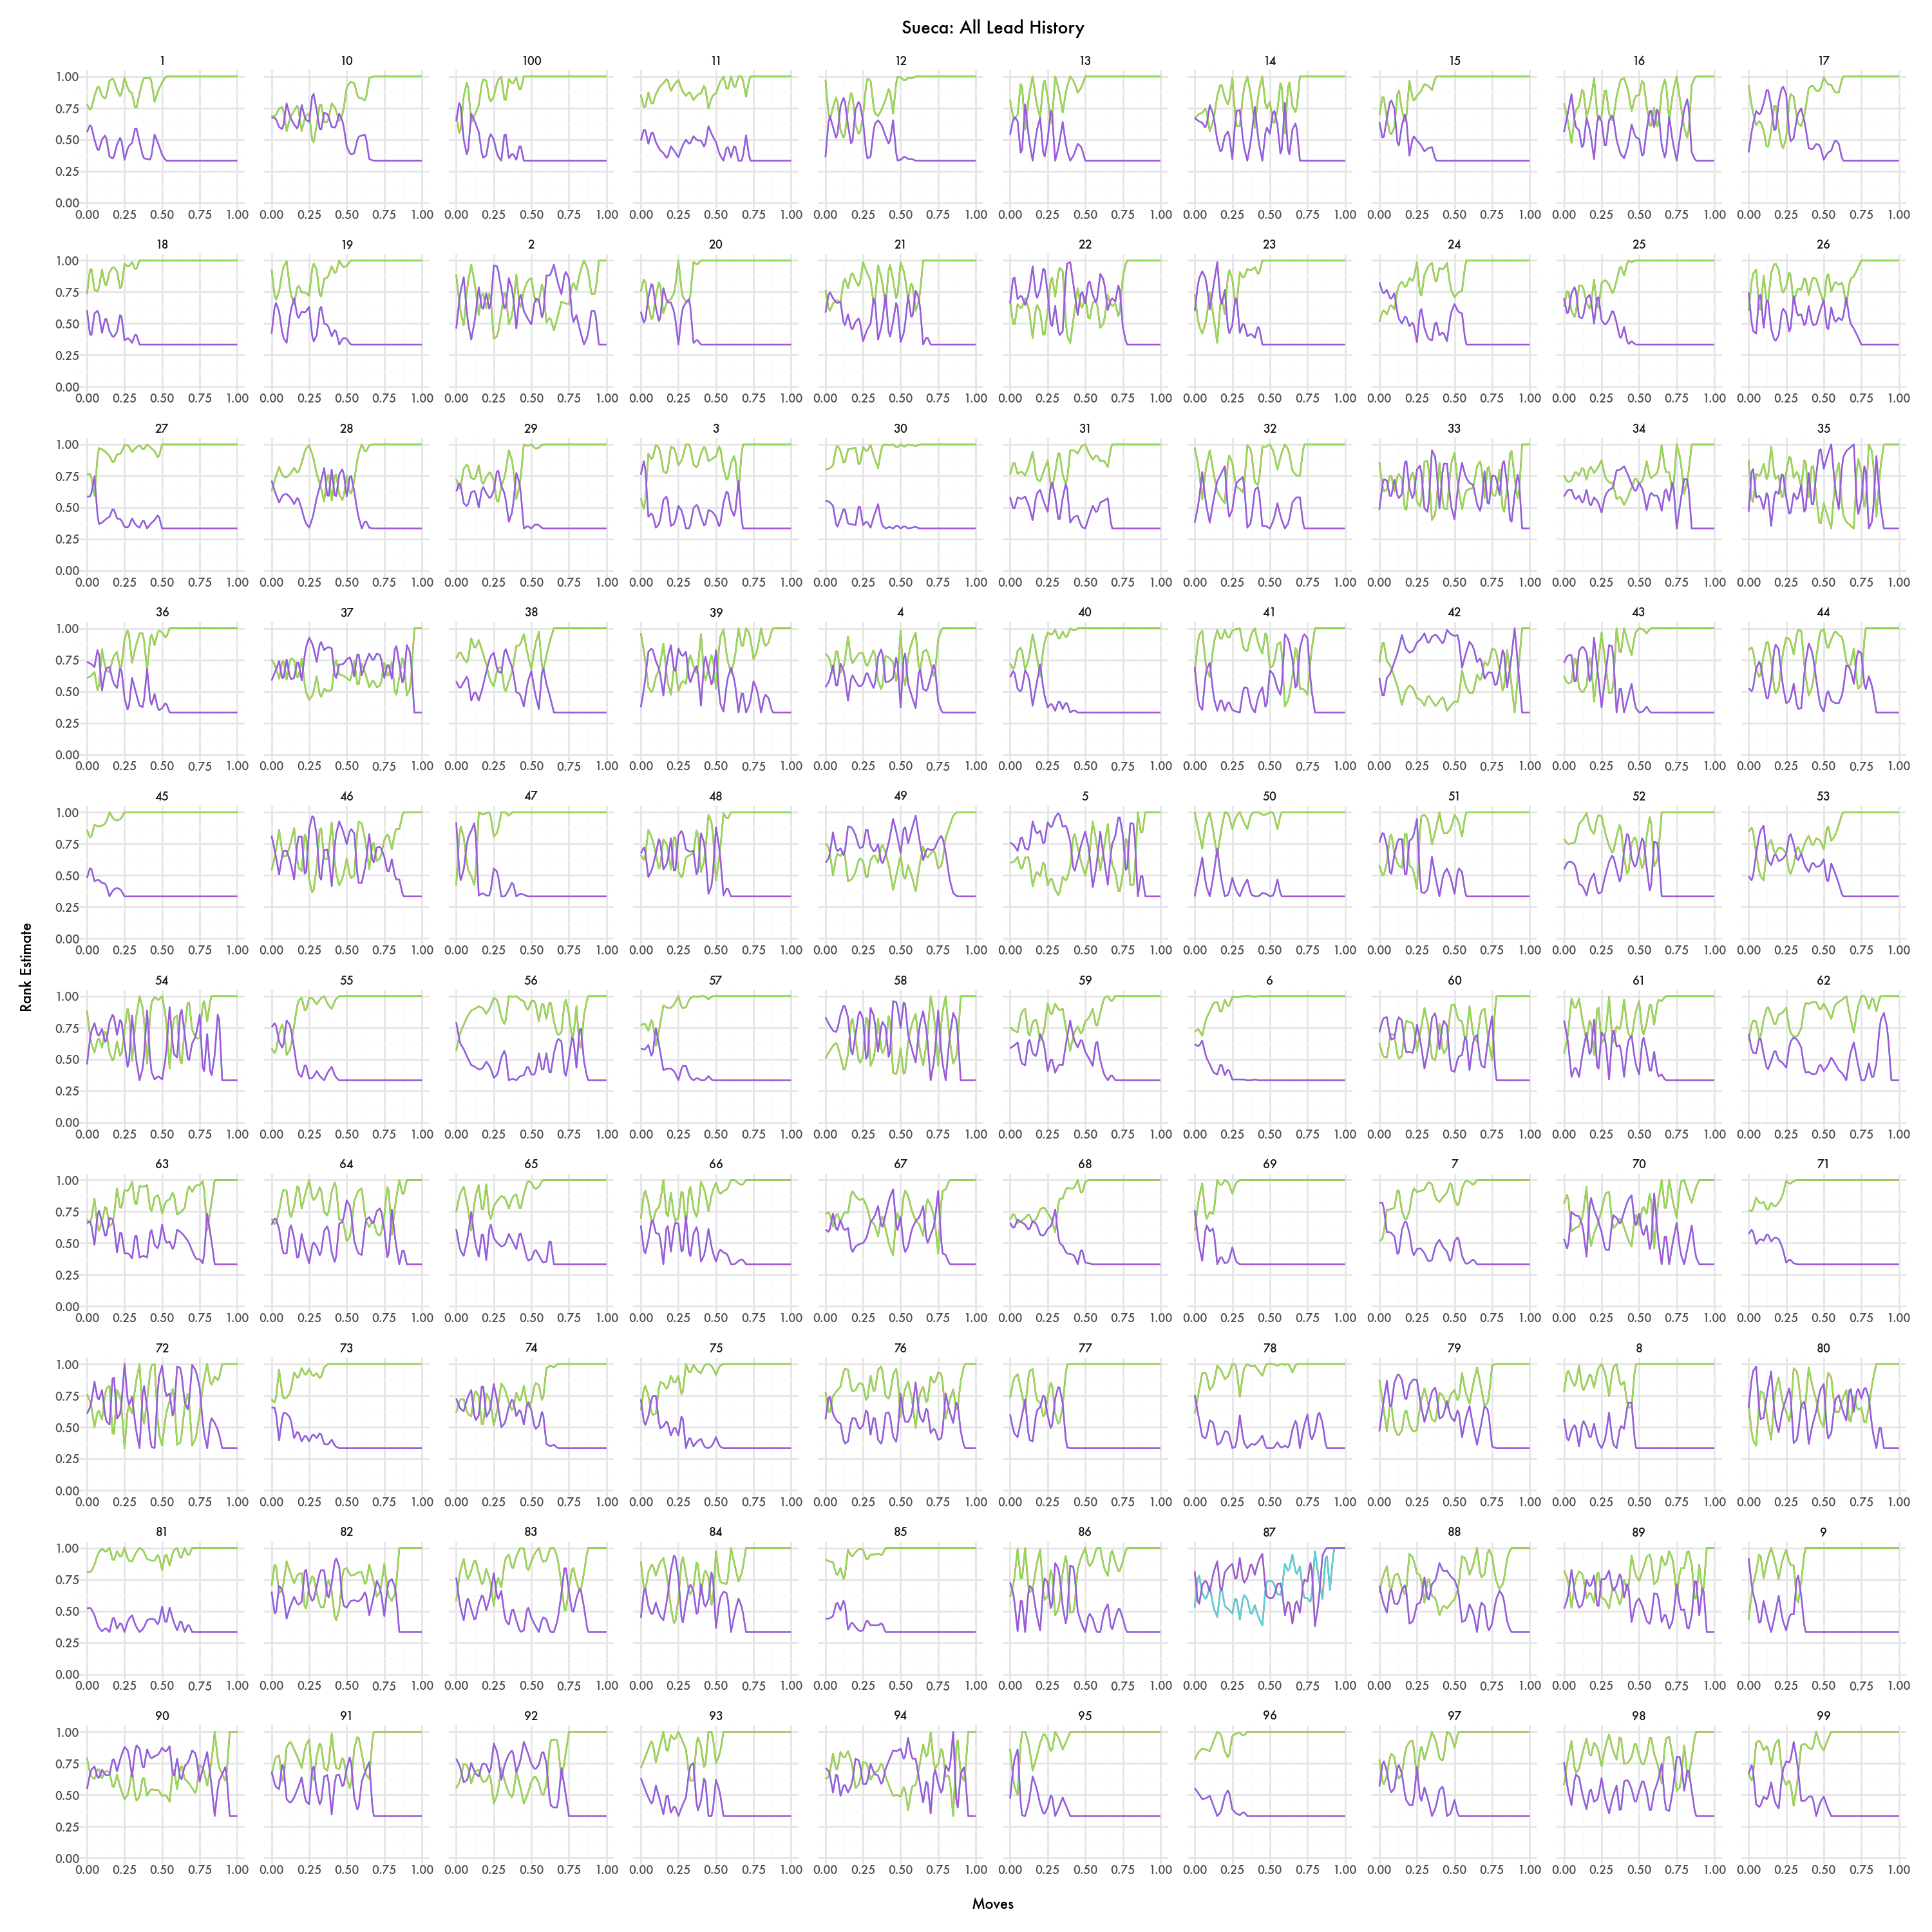

In [69]:
(ggplot(leads[(leads["game"] == game)], 
       aes(x="portion", y="estimate", color="rank"))
 + geom_line()
 + ylim(0, 1)
 + facet_wrap("run", scales = "free_x")
 + theme_minimal(base_family="Futura", base_size=8)
 + theme(legend_position='none', figure_size=(15, 15))
 + labs(x='Moves', y='Rank Estimate', title=game + ": All Lead History")
)

/opt/anaconda3/lib/python3.13/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_smooth : Removed 4 rows containing missing values.


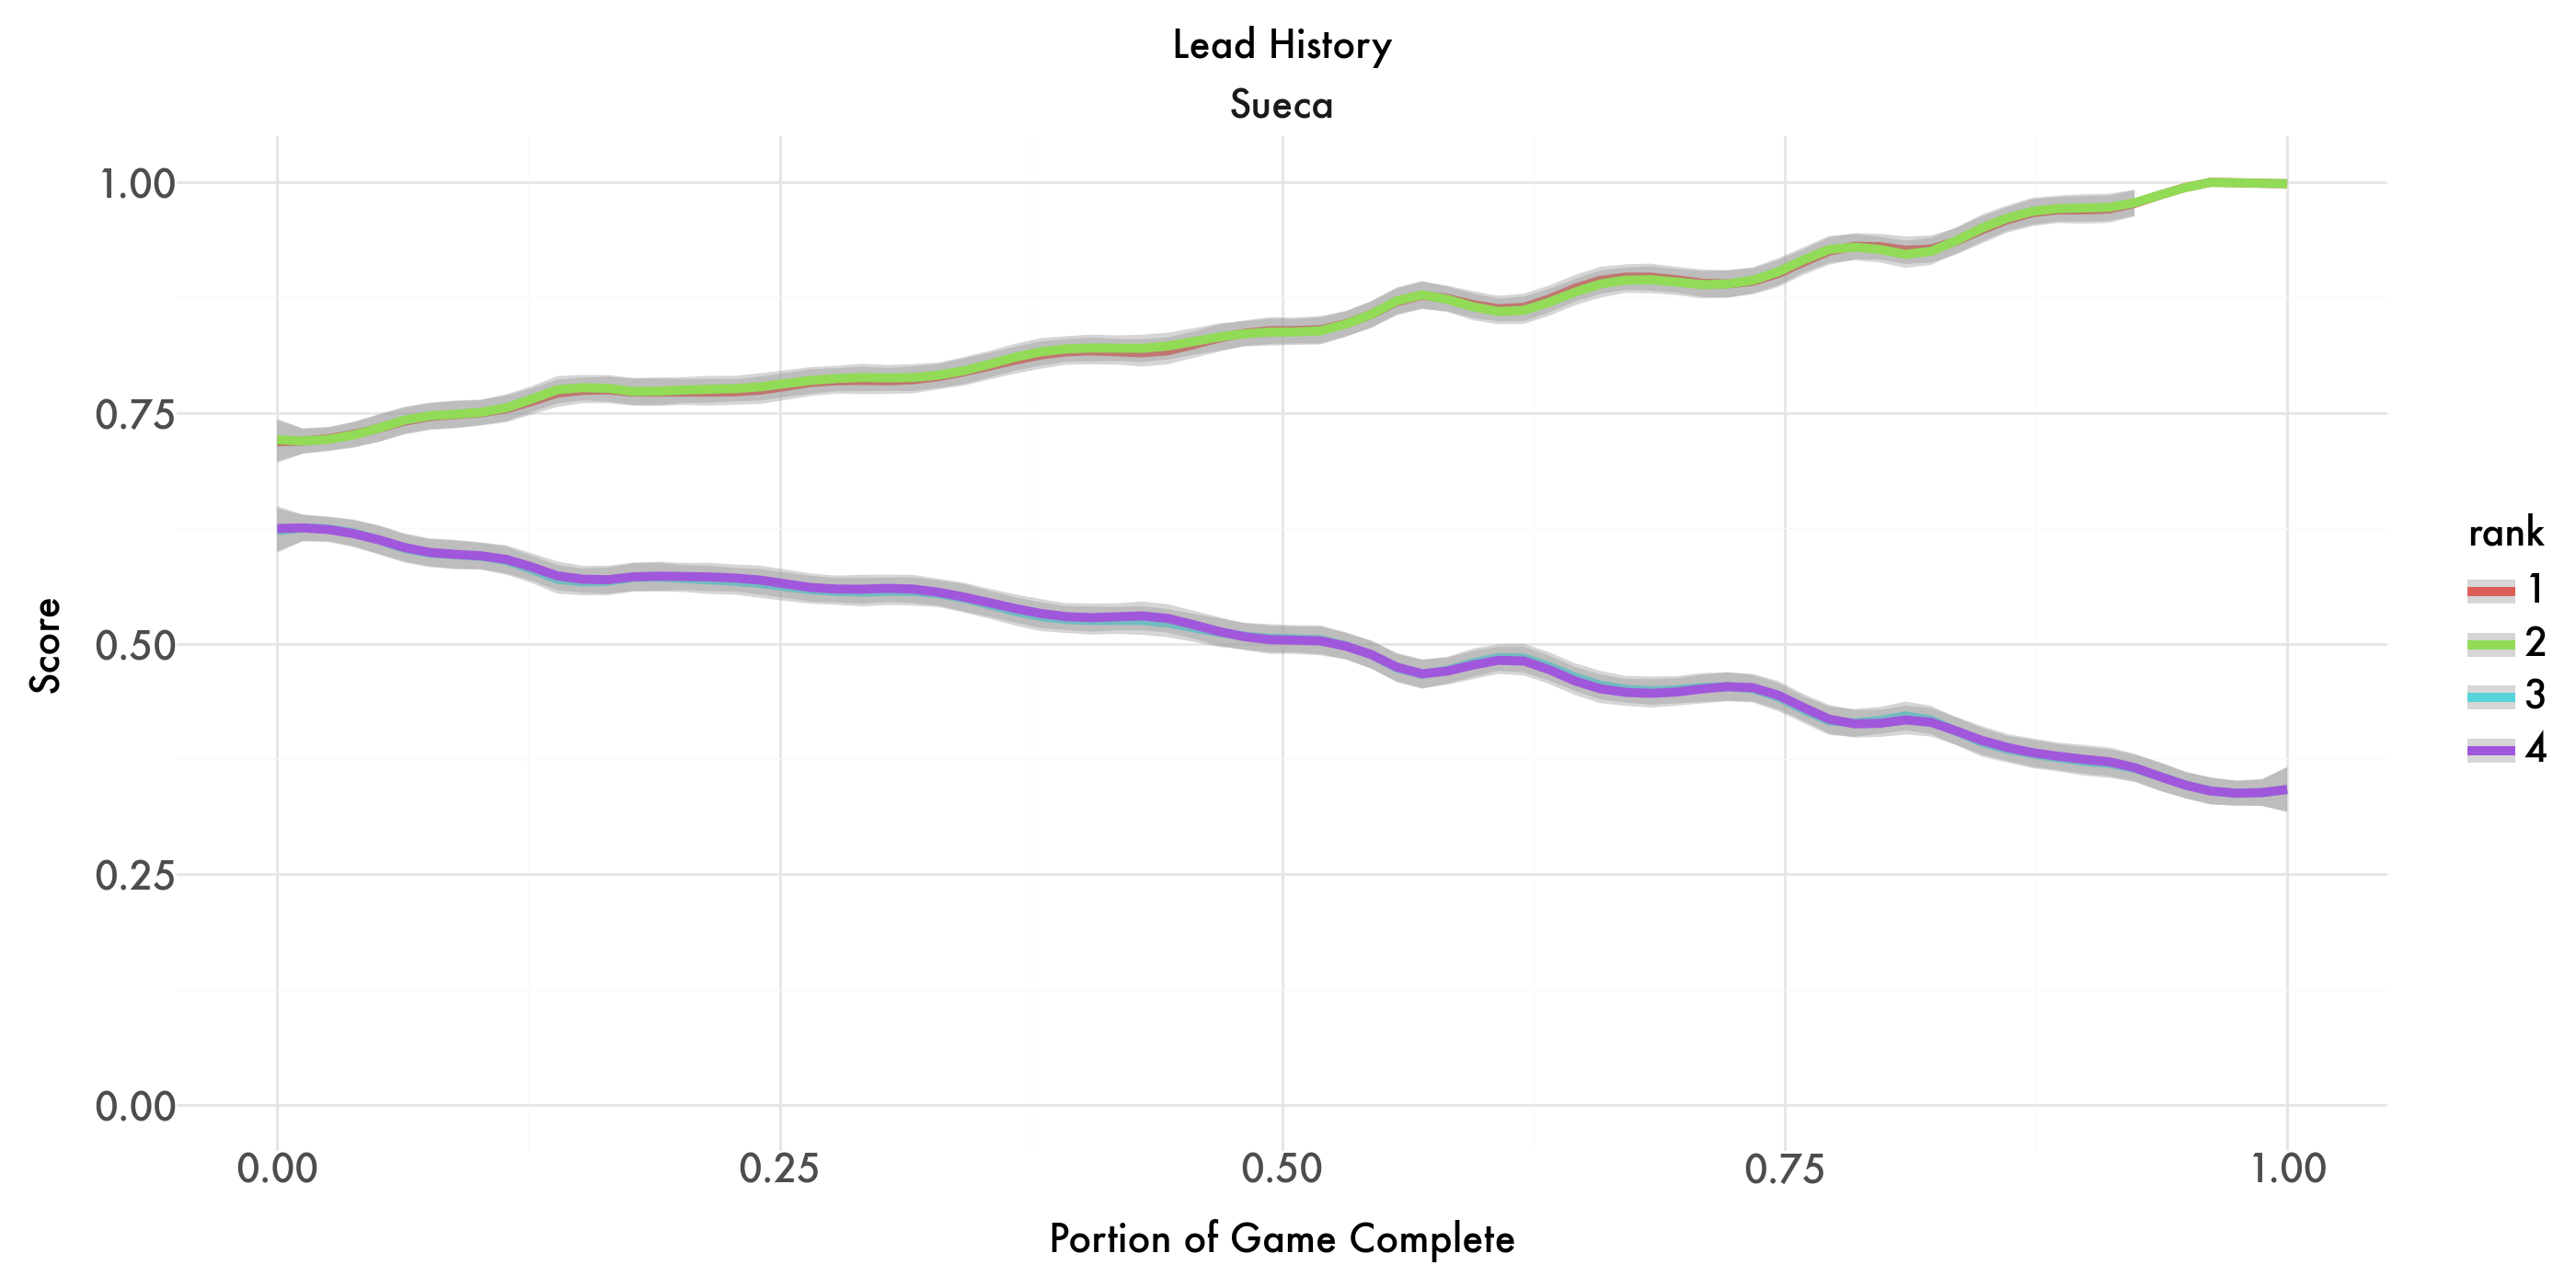

In [70]:

(ggplot(leads[(leads["game"] == game)], 
       aes(x="portion", y="estimate", color="rank"))
    + geom_smooth(method="loess", size=2, span=0.1)
    + ylim(0, 1)
    + facet_wrap("game")
    + theme_minimal(base_family="Futura", base_size=13)
    + theme(figure_size=(14, 7), text=element_text(size=15))
    + labs(x='Portion of Game Complete', y='Score', title="Lead History")
)


/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 10 x 5 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: LeadHistory.png
/opt/anaconda3/lib/python3.13/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_smooth : Removed 46 rows containing missing values.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_smooth : Removed 46 rows containing missing values.


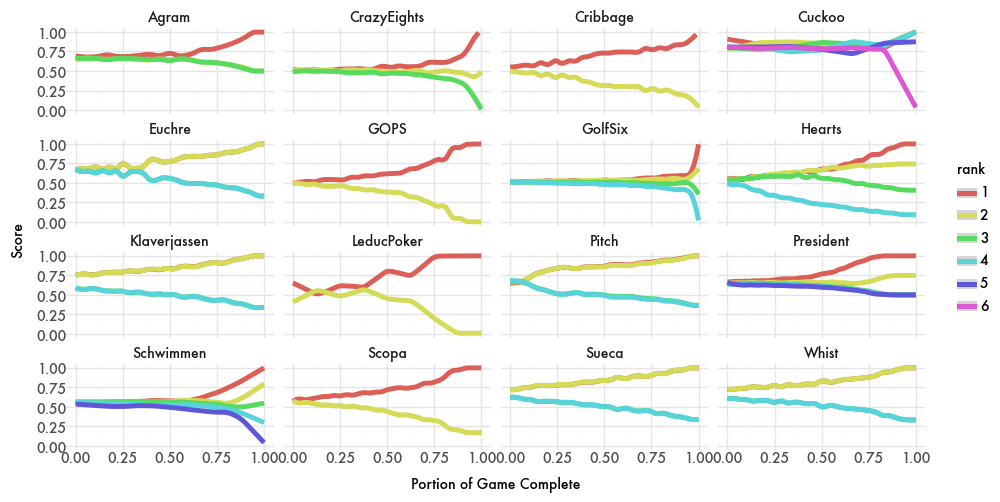

In [74]:
lh = (ggplot(leads, aes(x="portion", y="estimate", color="rank"))
    + geom_smooth(method="loess", size=2, span=0.1)
    + ylim(0, 1)
    + facet_wrap("game")
    + theme_minimal(base_family="Futura", base_size=10)
    + theme(figure_size=(10, 5), text=element_text(size=10))
    + labs(x='Portion of Game Complete', y='Score')
)
lh.save("LeadHistory.png")
lh.show()

In [60]:
(ggplot(leads, aes(x="portion", y="estimate", color="rank"))
    + geom_smooth(method="loess", size=2, span=0.1)
    + ylim(0, 1)
    + facet_wrap("game")
    + theme_minimal(base_family="Futura", base_size=10)
    + theme(figure_size=(14, 7), text=element_text(size=10))
    + labs(x='Portion of Game Complete', y='Score', title="Lead History")
)

KeyboardInterrupt: 

Use the following graph to look for turn order advantage.

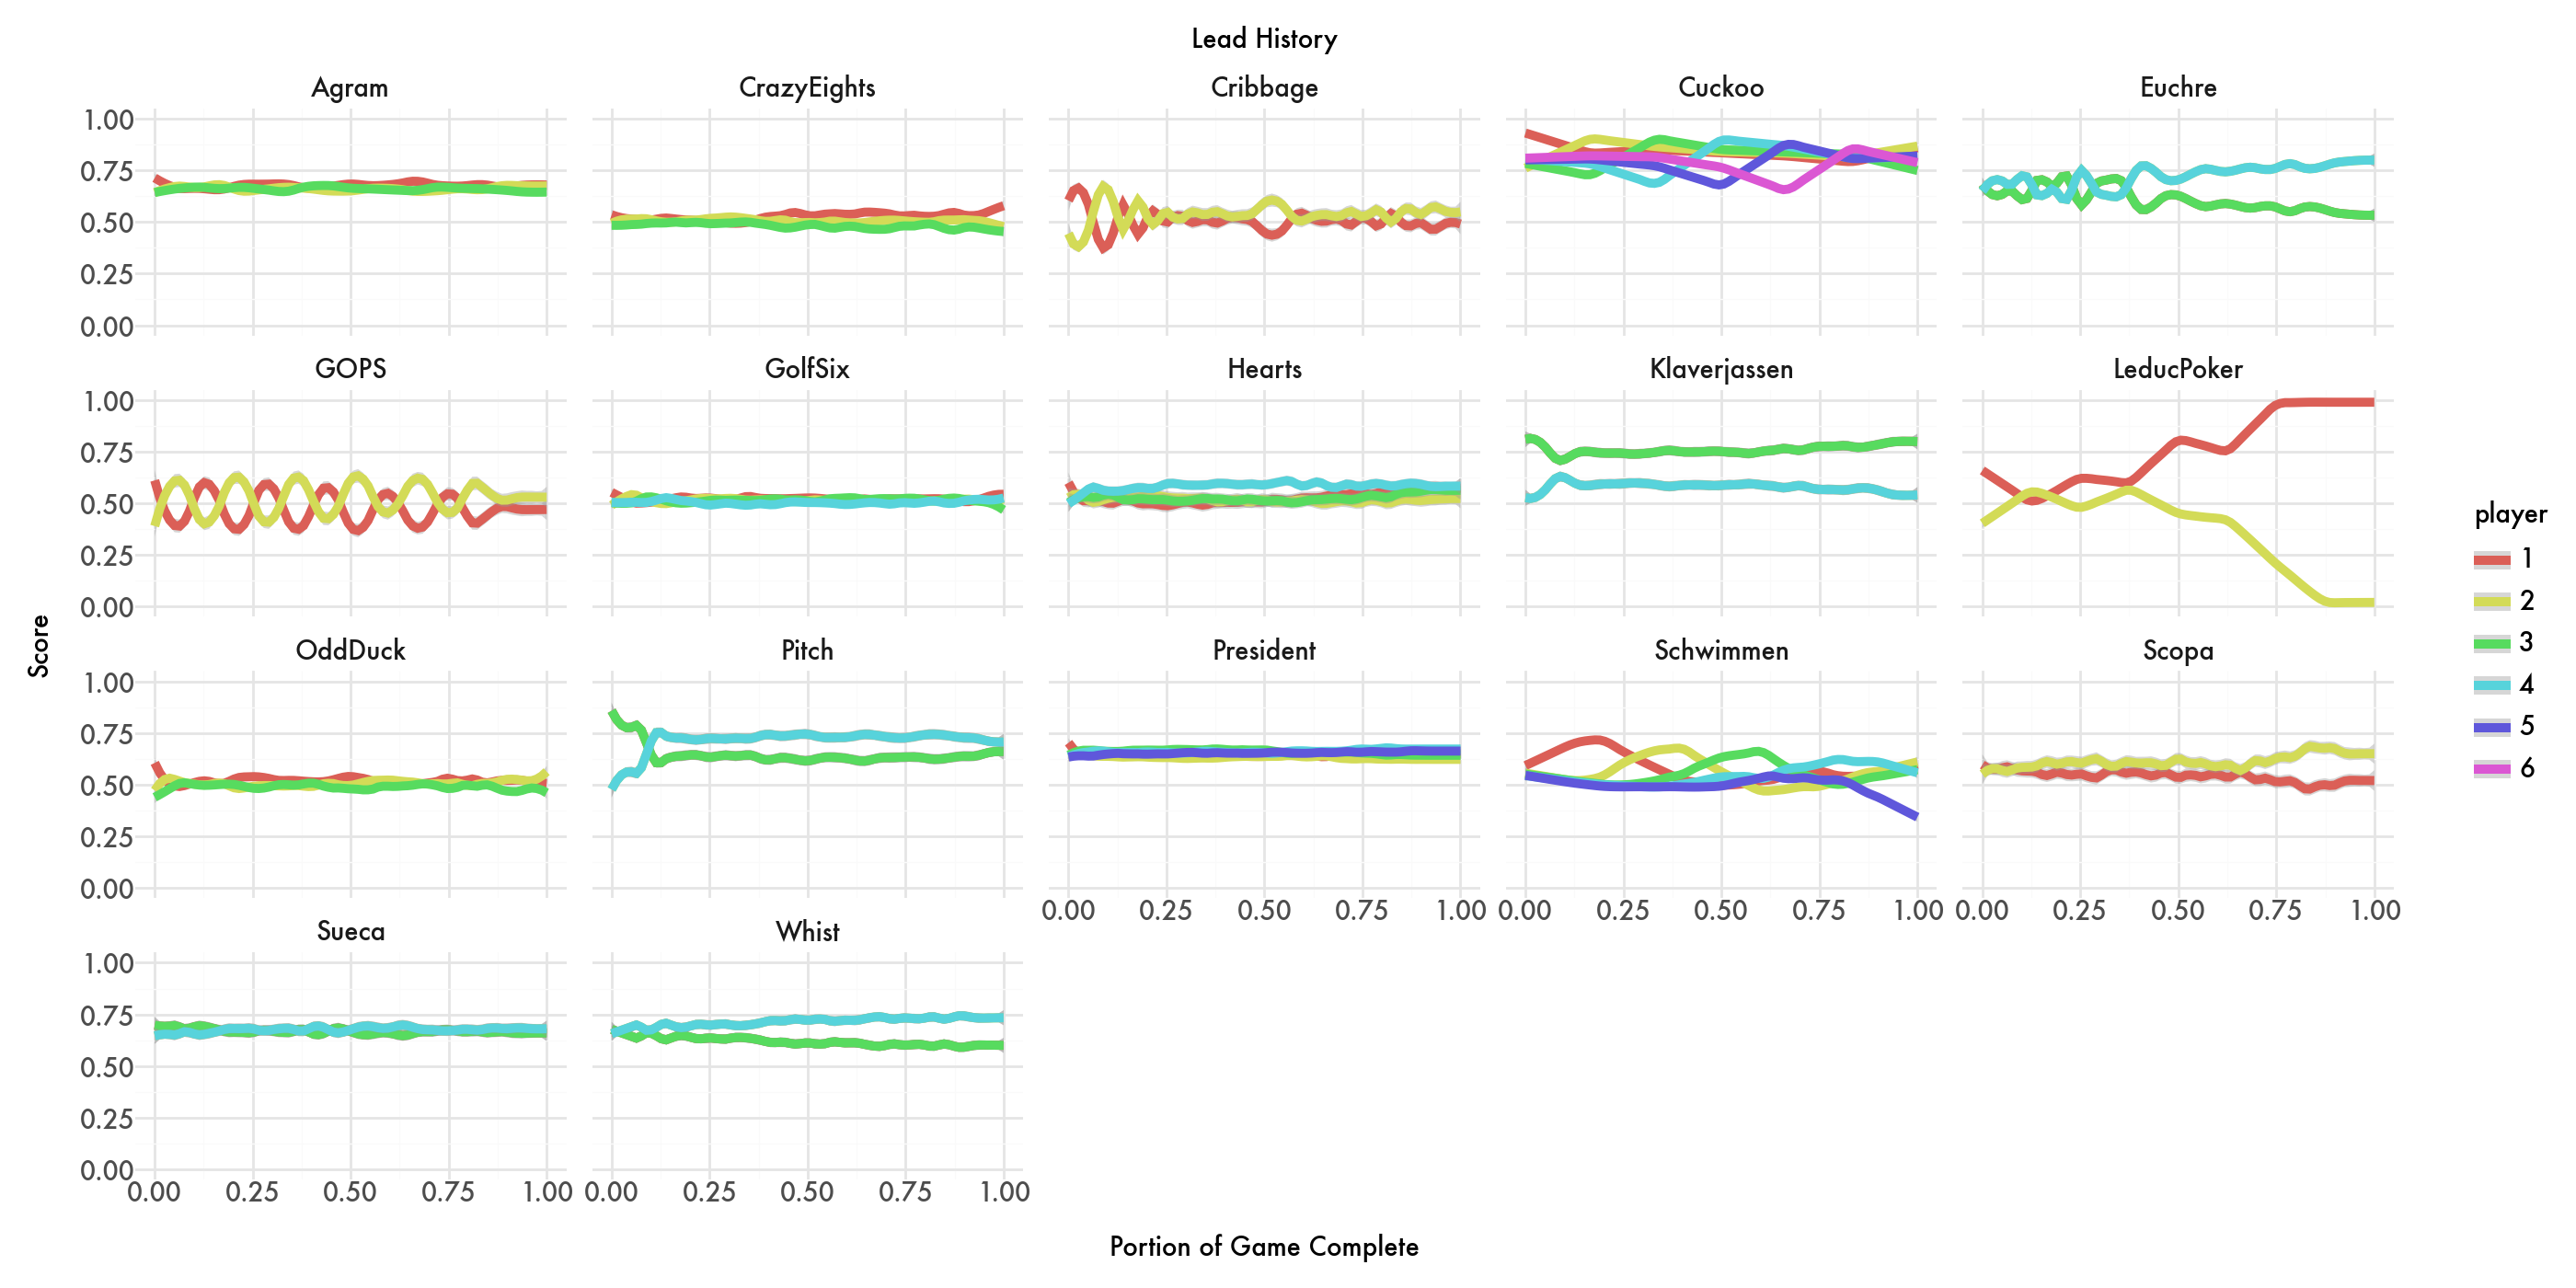

In [13]:
(ggplot(leads, aes(x="portion", y="estimate", color="player"))
    + geom_smooth(method="loess", size=2, span=0.1)
    + ylim(0, 1)
    + facet_wrap("game")
    + theme_minimal(base_family="Futura", base_size=10)
    + theme(figure_size=(14, 7), text=element_text(size=10))
    + labs(x='Portion of Game Complete', y='Score', title="Lead History")
)

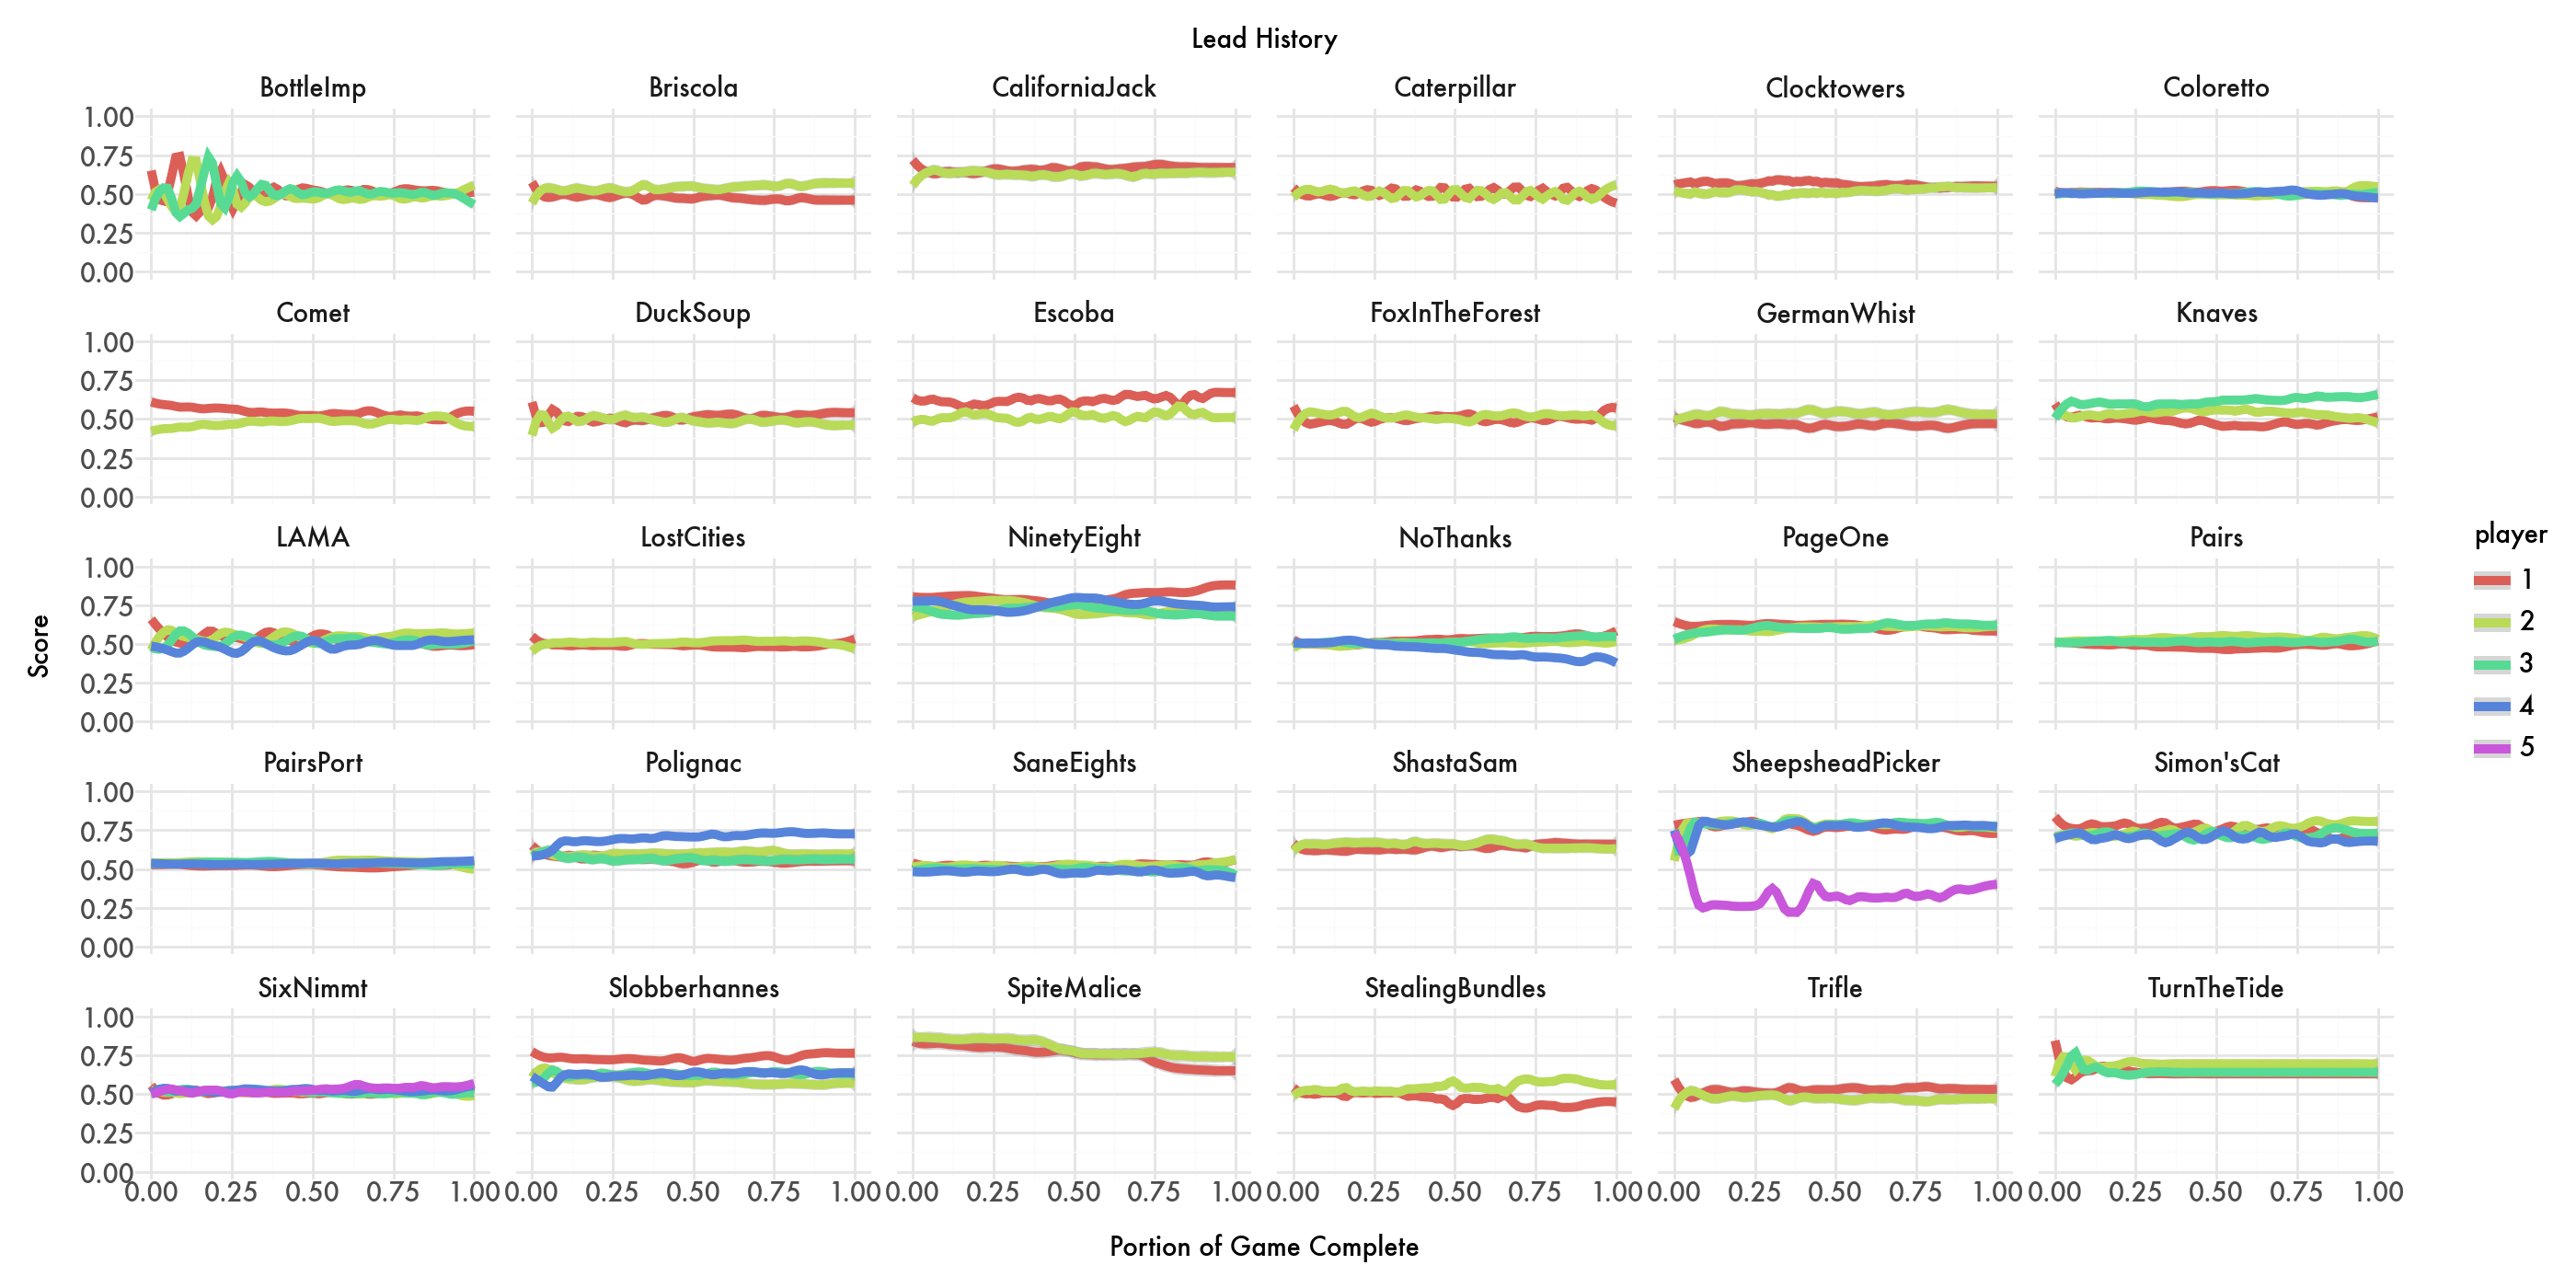

In [17]:
(ggplot(leads, aes(x="portion", y="estimate", color="player"))
    + geom_smooth(method="loess", size=2, span=0.1)
    + ylim(0, 1)
    + facet_wrap("game")
    + theme_minimal(base_family="Futura", base_size=10)
    + theme(figure_size=(14, 7), text=element_text(size=10))
    + labs(x='Portion of Game Complete', y='Score', title="Lead History")
)